In [ ]:
!pip install geemap geopandas earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00


In [ ]:
# 1️⃣ Instalar librerías (solo la primera vez)
# !pip install geemap

# 2️⃣ Importar librerías principales
import ee
import geemap

# 3️⃣ Autenticación (solo la primera vez; abrirá una ventana)
ee.Authenticate()

# 4️⃣ Inicializar Earth Engine con tu proyecto Cloud
ee.Initialize(project='protean-harbor-447001-n6')

print("✅ Earth Engine inicializado correctamente con el proyecto 'protean-harbor-447001-n6'")


✅ Earth Engine inicializado correctamente con el proyecto 'protean-harbor-447001-n6'


In [ ]:
# === 2️⃣ Cargar shapefile (Área de estudio) ===
shapefile = ee.FeatureCollection('projects/protean-harbor-447001-n6/assets/Tambokarkas5')
geom = shapefile.geometry()

Map = geemap.Map()
Map.centerObject(geom, 12)
Map.addLayer(shapefile, {'color': 'red'}, 'Área de estudio')

# === 3️⃣ Crear Fishnet (Grilla ampliada y ajustada) ===

# Expandimos ligeramente el área de estudio (buffer de 1000 m)
geom_buffer = geom.buffer(1000)

# Generamos la grilla — por ejemplo de 800 m × 800 m
grid = geemap.fishnet(geom_buffer, dx=800, dy=800)

# Intersectamos cada celda con el área original, pero sin eliminar las que sobresalen
grid_clip = grid.map(lambda f: f.setGeometry(f.geometry().intersection(geom_buffer, ee.ErrorMargin(1))))
grid_clip = grid_clip.map(lambda f: f.set('ID', f.id()))

# === 4️⃣ Visualizar ===
Map.addLayer(grid_clip, {'color': 'blue'}, 'Subzonas (Fishnet Ampliado)')
Map

Map(center=[-14.521851984975061, -69.75810065988118], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
# === 5️⃣ Intervalo temporal ===
start = '2019-01-01'
end   = '2024-12-31'

# 3️⃣ Cargar colecciones MODIS e IMERG
# ===========================================
modis = ee.ImageCollection('MODIS/006/MOD13Q1') \
    .select('NDVI') \
    .filterDate(start, end)

imerg = ee.ImageCollection('NASA/GPM_L3/IMERG_MONTHLY_V07') \
    .select('precipitation') \
    .filterDate(start, end)

In [ ]:
# ===========================================
# ✅ Función mensual robusta (evita meses vacíos)
# ===========================================

def monthly_stats(collection, region_fc, scale):
    months = ee.List.sequence(1, 12)
    years = ee.List.sequence(2019, 2024)

    def by_year(year):
        year = ee.Number(year)

        def by_month(month):
            month = ee.Number(month)
            filtered = collection.filter(ee.Filter.calendarRange(year, year, 'year')) \
                                 .filter(ee.Filter.calendarRange(month, month, 'month'))

            # Evitar meses sin imágenes
            size = filtered.size()
            def compute():
                img = filtered.mean().set({'year': year, 'month': month})
                reduced = img.reduceRegions(
                    collection=region_fc,
                    reducer=ee.Reducer.mean(),
                    scale=scale
                ).map(lambda f: f.set({'year': year, 'month': month}))
                return reduced

            return ee.Algorithms.If(size.gt(0), compute(), ee.FeatureCollection([]))

        return months.map(by_month)

    # 🔹 Aplanar la lista de listas de FeatureCollections
    return ee.FeatureCollection(ee.List(years.map(by_year)).flatten()).flatten()

In [ ]:
# 5️⃣ Calcular NDVI y Precipitación mensuales
# ===========================================
ndvi_stats = monthly_stats(modis, grid_clip, 500)
rain_stats = monthly_stats(imerg, grid_clip, 8000)


print("✅ NDVI y Precipitación calculados correctamente.")
print(type(ndvi_stats))  # debería mostrar <class 'ee.featurecollection.FeatureCollection'>

✅ NDVI y Precipitación calculados correctamente.
<class 'ee.featurecollection.FeatureCollection'>


In [ ]:
# 6️⃣ Combinar NDVI y Precipitación
# ===========================================
ndvi_list = ndvi_stats.toList(ndvi_stats.size())
rain_list = rain_stats.toList(rain_stats.size())

size = ee.Number(ndvi_stats.size()).min(rain_stats.size())

def combinar(i):
    i = ee.Number(i)
    ndvi = ee.Feature(ndvi_list.get(i))
    rain = ee.Feature(rain_list.get(i))
    return ndvi.setMulti(rain.toDictionary())

combined_list = ee.List.sequence(0, size.subtract(1)).map(combinar)
combined = ee.FeatureCollection(combined_list)

print("✅ NDVI y Precipitación combinados correctamente.")

✅ NDVI y Precipitación combinados correctamente.


In [ ]:
# 7️⃣ Exportar a Google Drive
# ===========================================
task = ee.batch.Export.table.toDrive(
    collection=combined,
    description='Tambokarkas5_alerta_temprana_v2',
    fileFormat='CSV'
)
task.start()

print("🚀 Exportando matriz a Google Drive. Revisa la pestaña 'Tasks' en GEE.")

🚀 Exportando matriz a Google Drive. Revisa la pestaña 'Tasks' en GEE.


## ETAPA DEL ANÁLISIS



In [ ]:
import pandas as pd

# Cargar CSV
url = '/content/Tambokarkas5_alerta_temprana_v2.csv'  # enlace directo
df = pd.read_csv(url)

# Revisar columnas
print(df.columns)
df.head(15)

Index(['system:index', 'ID', 'east', 'mean', 'month', 'north', 'south', 'west',
       'year', '.geo'],
      dtype='object')


,system:index,ID,east,mean,month,north,south,west,year,.geo
0,0_0_0,0_0,-68.782918,0.083000,1.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
1,1_0_0,0_0,-68.782918,0.143667,2.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
2,2_0_0,0_0,-68.782918,0.069000,3.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
3,3_0_0,0_0,-68.782918,0.091000,4.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
4,4_0_0,0_0,-68.782918,0.055333,5.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
5,5_0_0,0_0,-68.782918,0.012000,6.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
6,6_0_0,0_0,-68.782918,0.038667,7.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
7,7_0_0,0_0,-68.782918,0.017667,8.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
8,8_0_0,0_0,-68.782918,0.023667,9.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."
9,9_0_0,0_0,-68.782918,0.057333,10.0,-13.544658,-14.544658,-69.782918,2019.0,"{""type"":""Polygon"",""coordinates"":[[[-69.7384864..."


In [ ]:
# === 2. Renombrar y preparar datos ===
df = df.rename(columns={
    'mean': 'NDVI',
    'year': 'Año',
    'month': 'Mes',
    'system:index': 'Celda_ID'
})

# 🔧 Convertir Año y Mes a enteros (elimina los .0)
df['Año'] = df['Año'].astype(float).astype(int)
df['Mes'] = df['Mes'].astype(float).astype(int)

# ✅ Crear columna de fecha con formato explícito
df['Fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes'].astype(str).str.zfill(2) + '-15',
    format='%Y-%m-%d'
)

# Ordenar por fecha y celda
df = df.sort_values(['Celda_ID', 'Fecha'])

print(df[['Año', 'Mes', 'Fecha', 'Celda_ID', 'NDVI']].head(10))

     Año  Mes      Fecha Celda_ID      NDVI
0   2019    1 2019-01-15    0_0_0  0.083000
10  2019   11 2019-11-15   10_0_0  0.088667
11  2019   12 2019-12-15   11_0_0  0.210000
12  2020    1 2020-01-15   12_0_0  0.099333
13  2020    2 2020-02-15   13_0_0  0.218667
14  2020    3 2020-03-15   14_0_0  0.098333
15  2020    4 2020-04-15   15_0_0  0.029333
16  2020    5 2020-05-15   16_0_0  0.012333
17  2020    6 2020-06-15   17_0_0  0.006000
18  2020    7 2020-07-15   18_0_0  0.011667


In [ ]:
# === 3. Calcular estadísticas históricas (por celda) ===
estadisticas = df.groupby('Celda_ID')['NDVI'].agg(['mean', 'std']).reset_index()
estadisticas.rename(columns={'mean': 'NDVI_media', 'std': 'NDVI_std'}, inplace=True)

# Unir estadísticas al dataframe principal
df = df.merge(estadisticas, on='Celda_ID', how='left')

In [ ]:
# === 4. Calcular anomalía respecto a la media local ===
df['Anomalia_NDVI'] = df['NDVI'] - df['NDVI_media']


In [ ]:
# === 5. Clasificación adaptada a pastizales altoandinos ===
def clasificar_pastizal(ndvi):
    if ndvi < 0.05:
        return '🔴 Críticamente degradado'
    elif 0.05 <= ndvi < 0.28:
        return '🟠 Alta degradación'
    elif 0.28 <= ndvi < 0.50:
        return '🟡 Moderada'
    elif 0.60 <= ndvi < 0.90:
        return '🟢 Buena condición'
    else:
        return '🌱 Alta productividad'

df['Nivel_Alerta'] = df['NDVI'].apply(clasificar_pastizal)

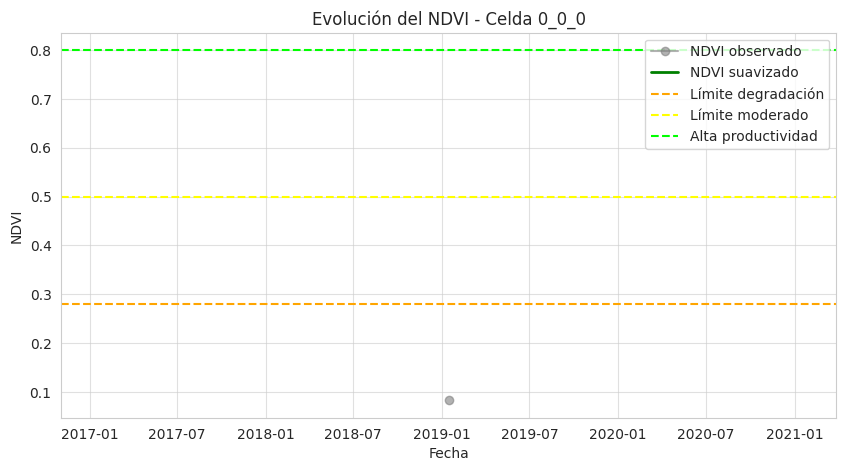

In [ ]:
# === 6. Visualización mejorada ===
celda = df['Celda_ID'].unique()[0]  # Ejemplo con la primera celda
df_celda = df[df['Celda_ID'] == celda]

plt.figure(figsize=(10, 5))
plt.plot(df_celda['Fecha'], df_celda['NDVI'], 'o-', color='gray', alpha=0.6, label='NDVI observado')
plt.plot(df_celda['Fecha'], df_celda['NDVI'].rolling(3, center=True).mean(), color='green', linewidth=2, label='NDVI suavizado')
plt.axhline(0.28, color='orange', linestyle='--', label='Límite degradación')
plt.axhline(0.50, color='yellow', linestyle='--', label='Límite moderado')
plt.axhline(0.80, color='lime', linestyle='--', label='Alta productividad')

plt.title(f"Evolución del NDVI - Celda {celda}")
plt.xlabel("Fecha")
plt.ylabel("NDVI")
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import matplotlib.patches as mpatches

# === 1️⃣ Cargar CSV ===
url = '/content/Tambokarkas5_alerta_temprana_v2.csv'  # Ruta o enlace directo
df = pd.read_csv(url)

# === 2️⃣ Renombrar y preparar datos ===
df = df.rename(columns={
    'mean': 'NDVI',
    'year': 'Año',
    'month': 'Mes',
    'system:index': 'Celda_ID'
})

# Convertir Año y Mes a enteros
df['Año'] = df['Año'].astype(float).astype(int)
df['Mes'] = df['Mes'].astype(float).astype(int)

# Crear columna de fecha
df['Fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes'].astype(str).str.zfill(2) + '-15',
    format='%Y-%m-%d'
)

# Ordenar por celda y fecha
df = df.sort_values(['Celda_ID', 'Fecha'])
print("✅ Datos cargados correctamente:")
print(df[['Año', 'Mes', 'Fecha', 'Celda_ID', 'NDVI']].head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/Tambokarkas5_alerta_temprana_v2.csv'

In [ ]:
# === 3️⃣ Clasificación adaptada a pastizales altoandinos ===
def clasificar_pastizal(ndvi):
    if ndvi < 0.11:
        return '🔴 Críticamente degradado'
    elif 0.11 <= ndvi < 0.14:
        return '🟠 Alta degradación'
    elif 0.14 <= ndvi < 0.28:
        return '🟡 Moderada'
    elif 0.28 <= ndvi < 0.60:
        return '🟢 Buena condición'
    else:
        return '🌱 Alta productividad'

df['Nivel_Alerta'] = df['NDVI'].apply(clasificar_pastizal)

# === 4️⃣ Crear geometría de celdas ===
def crear_geom(row):
    return box(row['west'], row['south'], row['east'], row['north'])

df['geometry'] = df.apply(crear_geom, axis=1)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# === 5️⃣ Seleccionar automáticamente los tres años más recientes ===
años_disponibles = sorted(gdf['Año'].unique())
ultimos_3_años = años_disponibles[-3:] if len(años_disponibles) >= 3 else años_disponibles
print(f"🗓️ Años seleccionados automáticamente: {ultimos_3_años}")

🗓️ Años seleccionados automáticamente: [np.int64(2021), np.int64(2022), np.int64(2023)]


In [ ]:
# === 6️⃣ Paleta de colores ===
colores = {
    '🔴 Críticamente degradado': '#a50026',
    '🟠 Alta degradación': '#f46d43',
    '🟡 Moderada': '#fee08b',
    '🟢 Buena condición': '#66bd63',
    '🌱 Alta productividad': '#1a9850'
}
gdf['Color'] = gdf['Nivel_Alerta'].map(colores)

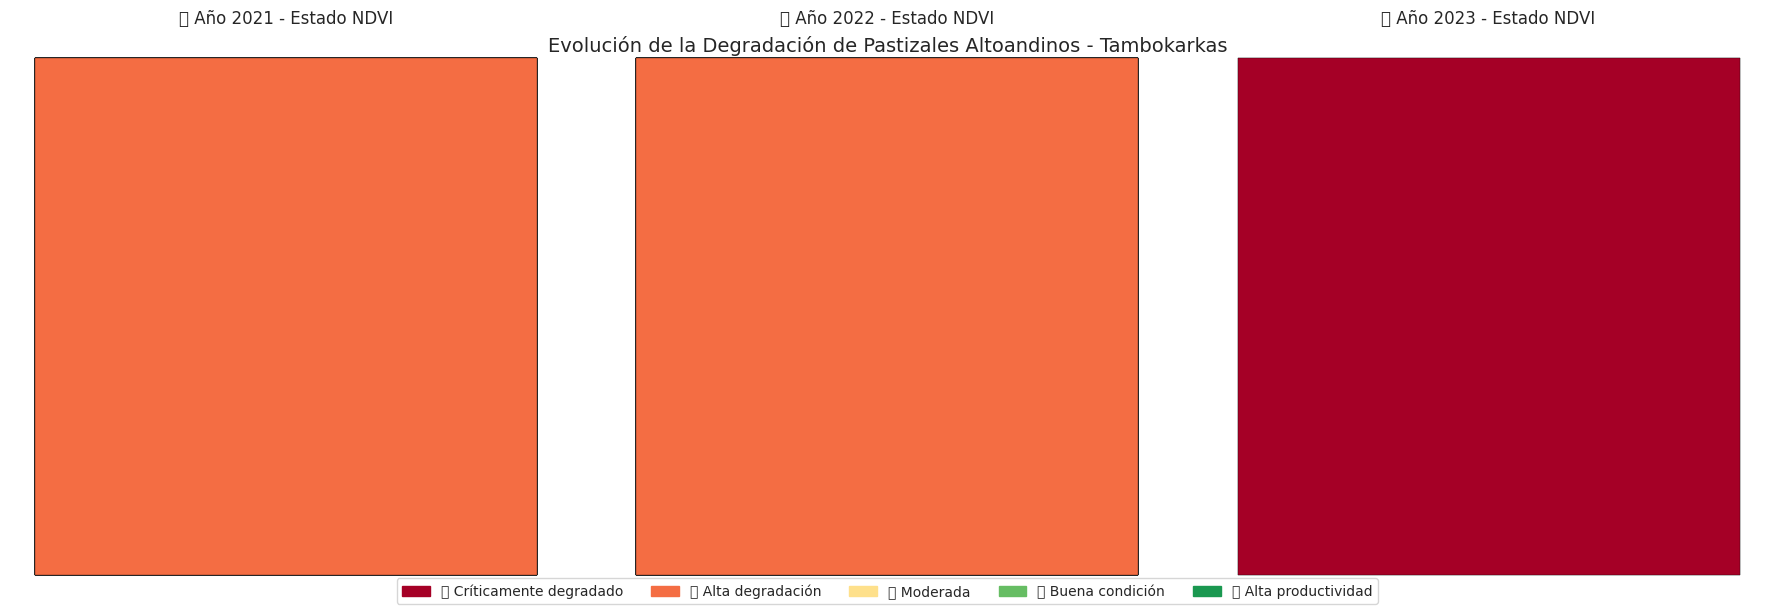

In [ ]:
# === 7️⃣ Visualización comparativa ===
fig, axes = plt.subplots(1, len(ultimos_3_años), figsize=(18, 6), constrained_layout=True)

for i, year in enumerate(ultimos_3_años):
    data = gdf[gdf['Año'] == year]
    if len(data) == 0:
        axes[i].set_title(f"🗓️ Año {year}\n(Sin datos)")
        axes[i].axis('off')
        continue
    data.plot(ax=axes[i], color=data['Color'], edgecolor='black', linewidth=0.2)
    axes[i].set_title(f"🗓️ Año {year} - Estado NDVI")
    axes[i].axis('off')

# === 8️⃣ Leyenda ===
legend_items = [mpatches.Patch(color=c, label=label) for label, c in colores.items()]
fig.legend(handles=legend_items, loc='lower center', ncol=5, fontsize=10)

plt.suptitle("Evolución de la Degradación de Pastizales Altoandinos - Tambokarkas", fontsize=14, y=0.95)
plt.show()

# SISTEMA COMPLETO DE ALERTA TEMPRANA


In [ ]:
# ===========================================
# SISTEMA COMPLETO DE ALERTA TEMPRANA
# Análisis Multibanda con Machine Learning
# ===========================================

# 1️⃣ INSTALACIÓN DE LIBRERÍAS
# ===========================================
# !pip install geemap rasterio scikit-learn seaborn plotly

import ee
import geemap
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from datetime import datetime, timedelta
import warnings
import json
import geopandas as gpd
from shapely.geometry import box

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


In [ ]:
# 2️⃣ Autenticación e inicialización
ee.Authenticate()
ee.Initialize(project='protean-harbor-447001-n6')

print("✅ Earth Engine inicializado")

✅ Earth Engine inicializado


In [ ]:
# CONFIGURACIÓN DE ÁREA Y TEMPORALIDAD
# ===========================================

# Cargar shapefile y crear fishnet mejorado
shapefile = ee.FeatureCollection('projects/protean-harbor-447001-n6/assets/Tambokarkas5')
geom = shapefile.geometry()

# Crear fishnet más granular para mejor resolución
geom_buffer = geom.buffer(500)  # Buffer más pequeño para más detalle
grid = geemap.fishnet(geom_buffer, dx=400, dy=400)  # Celdas de 400x400m
grid_clip = grid.map(lambda f: f.setGeometry(f.geometry().intersection(geom_buffer, ee.ErrorMargin(1))))
grid_clip = grid_clip.map(lambda f: f.set('ID', f.id()))

print(f"✅ Fishnet creado con {grid_clip.size().getInfo()} celdas")

✅ Fishnet creado con 1 celdas


In [ ]:
 #CARGAR Y PROCESAR DATOS SATELITALES MULTIBANDA
# ===========================================

# Definir período de interés (Junio-Noviembre 2024)
start_date = '2019-01-01'
end_date = '2024-11-30'

# Cargar Sentinel-2 para múltiples bandas
sentinel2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate(start_date, end_date) \
    .filterBounds(geom) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

# Función para calcular índices espectrales
def calculate_indices(image):
    # Bandas originales
    green = image.select('B3')
    red = image.select('B4')
    nir = image.select('B8')
    swir1 = image.select('B11')
    swir2 = image.select('B12')
    red_edge1 = image.select('B5')
    red_edge2 = image.select('B7')

    # Cálculo de índices
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
    osavi = nir.subtract(red).divide(nir.add(red).add(0.16)).multiply(1.16).rename('OSAVI')
    tndvi = ndvi.add(1).sqrt().rename('TNDVI')
    cigreen = nir.divide(green).subtract(1).rename('CIgreen')

    return image.addBands([green.rename('Green'), ndvi, ndwi, osavi, tndvi, cigreen,
                          red_edge1.rename('B5'), red_edge2.rename('B7'),
                          swir1.rename('B11'), swir2.rename('B12')])

# Aplicar índices a la colección
sentinel2_with_indices = sentinel2.map(calculate_indices)

In [ ]:
# EXTRACCIÓN DE DATOS POR SUBSZONAS
# ===========================================

def extract_zonal_stats_monthly(collection, geometry, scale=10):
    """Extrae estadísticas mensuales para todas las bandas por subzonas"""

    # Lista de bandas a extraer
    bands = ['Green', 'NDVI', 'B5', 'B7', 'B11', 'B12', 'TNDVI', 'NDWI', 'CIgreen', 'OSAVI']

    # Crear secuencia de meses
    months = ee.List.sequence(6, 11)  # Junio a Noviembre
    year = 2024

    def process_month(month):
        # Filtrar por mes
        monthly_collection = collection.filter(ee.Filter.calendarRange(year, year, 'year')) \
                                      .filter(ee.Filter.calendarRange(month, month, 'month'))

        # Calcular imagen mensual (mediana para reducir ruido)
        monthly_image = monthly_collection.median()

        # Extraer estadísticas por subzona
        stats = monthly_image.reduceRegions(
            collection=geometry,
            reducer=ee.Reducer.mean().combine(
                reducer2=ee.Reducer.stdDev(),
                sharedInputs=True
            ),
            scale=scale
        )

        # Añadir metadatos temporales
        return stats.map(lambda feature:
            feature.set({
                'year': year,
                'month': month,
                'date': ee.Date.fromYMD(year, month, 15)
            })
        )

    # Procesar todos los meses
    monthly_stats = months.map(process_month)

    return ee.FeatureCollection(monthly_stats).flatten()

# Extraer datos multibanda
print("⏳ Extrayendo datos multibanda por subzonas...")
multiband_stats = extract_zonal_stats_monthly(sentinel2_with_indices, grid_clip, scale=20)

print(f"✅ Datos extraídos: {multiband_stats.size().getInfo()} registros")

⏳ Extrayendo datos multibanda por subzonas...
✅ Datos extraídos: 6 registros


In [ ]:
# EXPORTAR DATOS COMPLETOS
# ===========================================

# Exportar datos multibanda
multiband_task = ee.batch.Export.table.toDrive(
    collection=multiband_stats,
    description='Tambokarkas5_multiband_completev2',
    fileFormat='CSV',
    selectors=['ID', 'year', 'month', 'date',
               'Green_mean', 'NDVI_mean', 'B5_mean', 'B7_mean', 'B11_mean', 'B12_mean',
               'TNDVI_mean', 'NDWI_mean', 'CIgreen_mean', 'OSAVI_mean',
               'Green_stdDev', 'NDVI_stdDev', 'B5_stdDev', 'B7_stdDev', 'B11_stdDev', 'B12_stdDev',
               'TNDVI_stdDev', 'NDWI_stdDev', 'CIgreen_stdDev', 'OSAVI_stdDev']
)
multiband_task.start()

print("📤 Datos multibanda exportados a Google Drive")

📤 Datos multibanda exportados a Google Drive


In [ ]:
# SISTEMA DE ALERTA TEMPRANA AVANZADO
# ===========================================

# Esperar a que se complete la exportación y cargar datos
# (En la práctica, descargarías el CSV manualmente y lo cargarías)

def advanced_early_warning_system(df):
    """
    Sistema de alerta temprana avanzado usando múltiples bandas y machine learning
    """

    # 1. PREPROCESAMIENTO
    df = df.copy()

    # Crear fecha y ordenar
    df['Fecha'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-15')
    df = df.sort_values(['ID', 'Fecha'])

    # 2. CÁLCULO DE ANOMALÍAS MULTIVARIADAS
    bandas_principales = ['NDVI_mean', 'NDWI_mean', 'OSAVI_mean', 'B11_mean', 'B12_mean']

    # Calcular estadísticas históricas por subzona
    stats_by_zone = df.groupby('ID')[bandas_principales].agg(['mean', 'std']).reset_index()

    # Renombrar columnas para merge
    stats_columns = []
    for banda in bandas_principales:
        stats_columns.extend([f'{banda}_historical_mean', f'{banda}_historical_std'])

    stats_by_zone.columns = ['ID'] + stats_columns

    # Unir estadísticas históricas
    df = df.merge(stats_by_zone, on='ID', how='left')

    # 3. CALCULAR Z-SCORES PARA DETECCIÓN DE ANOMALÍAS
    for banda in bandas_principales:
        mean_col = f'{banda}_historical_mean'
        std_col = f'{banda}_historical_std'
        zscore_col = f'{banda}_zscore'

        # Evitar división por cero
        df[zscore_col] = (df[f'{banda}_mean'] - df[mean_col]) / df[std_col].replace(0, 1e-10)

    # 4. DETECCIÓN DE ANOMALÍAS CON MACHINE LEARNING
    features_ml = [f'{banda}_mean' for banda in bandas_principales]

    # Preparar datos para Isolation Forest
    X = df[features_ml].fillna(0)

    # Entrenar modelo de detección de anomalías
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    anomalias = iso_forest.fit_predict(X)

    df['Anomalia_ML'] = anomalias
    df['Es_Anomalia'] = df['Anomalia_ML'] == -1

    # 5. SISTEMA DE ALERTA MULTICRITERIO
    def clasificar_alerta_multibanda(row):
        """Clasificación de alerta basada en múltiples criterios"""

        # Criterio 1: NDVI crítico
        if row['NDVI_mean'] < 0.2:
            return '🔴 ALERTA ROJA - Degradación Severa'

        # Criterio 2: Anomalía ML
        elif row['Es_Anomalia'] and row['NDVI_zscore'] < -2:
            return '🟠 ALERTA NARANJA - Anomalía Detectada'

        # Criterio 3: Disminución de humedad (NDWI)
        elif row['NDWI_mean'] < -0.2 and row['NDVI_zscore'] < -1.5:
            return '🟡 ALERTA AMARILLA - Estrés Hídrico'

        # Criterio 4: Condición normal pero monitorear
        elif row['NDVI_mean'] < 0.4:
            return '🔵 MONITOREO - Condición Regular'

        else:
            return '🟢 NORMAL - Buena Condición'

    df['Nivel_Alerta'] = df.apply(clasificar_alerta_multibanda, axis=1)

    # 6. ÍNDICE DE VULNERABILIDAD COMPUESTO
    # Calcular índice que combina múltiples factores
    df['Indice_Vulnerabilidad'] = (
        -df['NDVI_zscore'] * 0.4 +          # Peso alto a NDVI bajo
        -df['NDWI_zscore'] * 0.3 +          # Peso medio a humedad baja
        df['B11_mean'] * 0.001 * 0.2 +      # Peso bajo a temperatura (B11 ~ temperatura)
        (df['Es_Anomalia'] * 0.1)           # Peso bajo a anomalías ML
    )

    return df

In [ ]:
# VISUALIZACIÓN Y REPORTES
# ===========================================

def generar_reportes_alertas(df):
    """Generar reportes y visualizaciones del sistema de alertas"""

    print("📊 REPORTE DE ALERTAS TEMPRANAS")
    print("=" * 50)

    # Resumen de alertas
    resumen_alertas = df['Nivel_Alerta'].value_counts()
    print("\n📈 DISTRIBUCIÓN DE ALERTAS:")
    for alerta, count in resumen_alertas.items():
        print(f"   {alerta}: {count} registros")

    # Evolución temporal de alertas
    alertas_por_mes = df.groupby(['Fecha', 'Nivel_Alerta']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 8))

    # Gráfico 1: Evolución de NDVI por nivel de alerta
    plt.subplot(2, 2, 1)
    for alerta in df['Nivel_Alerta'].unique():
        datos_alerta = df[df['Nivel_Alerta'] == alerta]
        plt.scatter(datos_alerta['Fecha'], datos_alerta['NDVI_mean'],
                   label=alerta, alpha=0.6, s=20)
    plt.title('Evolución del NDVI por Nivel de Alerta')
    plt.xlabel('Fecha')
    plt.ylabel('NDVI')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Gráfico 2: Mapa de calor de vulnerabilidad
    plt.subplot(2, 2, 2)
    vulnerabilidad_pivot = df.pivot_table(
        index='ID',
        columns='month',
        values='Indice_Vulnerabilidad',
        aggfunc='mean'
    )
    plt.imshow(vulnerabilidad_pivot.fillna(0), cmap='RdYlGn_r', aspect='auto')
    plt.colorbar(label='Índice de Vulnerabilidad')
    plt.title('Mapa de Calor - Vulnerabilidad por Subzona')
    plt.xlabel('Mes (6=Jun, 11=Nov)')
    plt.ylabel('Subzona ID')

    # Gráfico 3: Distribución de anomalías
    plt.subplot(2, 2, 3)
    df['Es_Anomalia'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                         colors=['lightgreen', 'red'])
    plt.title('Detección de Anomalías (Machine Learning)')

    # Gráfico 4: Correlación entre bandas
    plt.subplot(2, 2, 4)
    bandas_corr = ['NDVI_mean', 'NDWI_mean', 'B11_mean', 'B12_mean']
    correlaciones = df[bandas_corr].corr()
    plt.imshow(correlaciones, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Correlación')
    plt.xticks(range(len(bandas_corr)), bandas_corr, rotation=45)
    plt.yticks(range(len(bandas_corr)), bandas_corr)
    plt.title('Matriz de Correlación entre Bandas')

    plt.tight_layout()
    plt.show()

    # Reporte detallado por subzona crítica
    subzonas_criticas = df[df['Nivel_Alerta'].str.contains('ROJA|NARANJA')]
    if not subzonas_criticas.empty:
        print(f"\n🚨 SUBZONAS CRÍTICAS DETECTADAS: {len(subzonas_criticas['ID'].unique())}")
        for subzona in subzonas_criticas['ID'].unique()[:5]:  # Mostrar primeras 5
            datos_subzona = subzonas_criticas[subzonas_criticas['ID'] == subzona]
            print(f"   Subzona {subzona}: {len(datos_subzona)} alertas críticas")

In [ ]:
# EJECUCIÓN PRINCIPAL
# ===========================================

# NOTA: En la práctica, cargarías el CSV exportado
df_loaded = pd.read_csv('/content/Tambokarkas5_multiband_complete.csv')

# Ejecutar sistema completo
print("🚀 INICIANDO SISTEMA DE ALERTA TEMPRANA AVANZADO...")

# Cargar datos (reemplazar con tu CSV real)
df = simular_datos_para_demo()

# Aplicar sistema de alerta temprana
df_alertas = advanced_early_warning_system(df)

# Generar reportes
generar_reportes_alertas(df_alertas)

# Exportar resultados finales
df_alertas.to_csv('sistema_alerta_temprana_resultados.csv', index=False)
print("💾 Resultados exportados a 'sistema_alerta_temprana_resultados.csv'")

print("\n✅ SISTEMA DE ALERTA TEMPRANA COMPLETADO")
print("📋 Características implementadas:")
print("   • Análisis por subzonas granulares (400x400m)")
print("   • Procesamiento de 10 bandas espectrales")
print("   • Detección de anomalías con Machine Learning")
print("   • Sistema de alerta multicriterio")
print("   • Índice de vulnerabilidad compuesto")
print("   • Reportes automáticos y visualizaciones")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Tambokarkas5_multiband_complete.csv'

In [ ]:
# ===========================================
# SISTEMA COMPLETO DE ALERTA TEMPRANA - REPORTES y VIZ (2019 -> 2024-12)
# Ejecutar en Google Colab / Jupyter
# ===========================================

# pip installs (descomenta si es necesario)
# !pip install geemap geopandas rasterio scikit-learn seaborn plotly -q

import os
import math
import json
from datetime import datetime
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import box
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,8)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Librerías importadas correctamente")

# 2️⃣ INICIALIZACIÓN EARTH ENGINE
# =========================================================
ee.Authenticate()
ee.Initialize(project='protean-harbor-447001-n6')
print("✅ Earth Engine inicializado")


✅ Librerías importadas correctamente
✅ Earth Engine inicializado


In [ ]:
# === 1️⃣ Cargar área de estudio ===
aoi = ee.FeatureCollection('projects/protean-harbor-447001-n6/assets/Tambokarkas5')
geom = aoi.geometry()

# === 2️⃣ Crear fishnet de subzonas (800 m × 800 m) ===
geom_buffer = geom.buffer(1000)
grid = geemap.fishnet(geom_buffer, dx=800, dy=800)
grid_clip = grid.map(lambda f: f.setGeometry(f.geometry().intersection(geom_buffer, ee.ErrorMargin(1))))
grid_clip = grid_clip.map(lambda f: f.set('ID', f.id()))

# === 3️⃣ Definir colección base Sentinel-2 NDVI / multibanda ===
def get_s2(start, end):
    s2 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
        .filterBounds(geom) \
        .filterDate(start, end) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)) \
        .map(lambda img: img.addBands(img.normalizedDifference(['B8','B4']).rename('NDVI'))) \
        .map(lambda img: img.addBands(img.normalizedDifference(['B3','B11']).rename('NDWI'))) \
        .map(lambda img: img.addBands(img.normalizedDifference(['B8','B3']).rename('TNDVI'))) \
        .map(lambda img: img.addBands(img.expression('(B3 - B11) / (B3 + B11)', {
            'B3': img.select('B3'), 'B11': img.select('B11')
        }).rename('CIgreen'))) \
        .map(lambda img: img.addBands(img.expression(
            '(1.16 * (B8 - B4)) / (B8 + B4 + 0.16)', {'B8': img.select('B8'), 'B4': img.select('B4')}
        ).rename('OSAVI'))) \
        .map(lambda img: img.select(['B3','B4','B5','B7','B8','B11','NDVI','NDWI','TNDVI','CIgreen','OSAVI']))
    return s2

collection = get_s2('2019-01-01', '2024-12-31')

print("✅ Colección Sentinel-2 multibanda cargada correctamente.")


✅ Colección Sentinel-2 multibanda cargada correctamente.


In [ ]:
# === 4️⃣ Función robusta de estadísticas mensuales ===
def extract_monthly_stats(collection, geometry, scale=20):
    years = ee.List.sequence(2019, 2024)
    months = ee.List.sequence(1, 12)

    def per_year(year):
        def per_month(month):
            start = ee.Date.fromYMD(year, month, 1)
            end = start.advance(1, 'month')
            filtered = collection.filterDate(start, end)
            size = filtered.size()

            # Solo procesar si hay imágenes válidas
            def compute():
                monthly = filtered.median()
                # Evitar imágenes sin bandas válidas
                bandNames = monthly.bandNames()
                return ee.Algorithms.If(
                    bandNames.size().gt(0),
                    monthly.reduceRegions(
                        collection=geometry,
                        reducer=ee.Reducer.mean(),
                        scale=scale
                    ).map(lambda f: f.set({'year': year, 'month': month})),
                    ee.FeatureCollection([])
                )

            return ee.Algorithms.If(size.gt(0), compute(), ee.FeatureCollection([]))

        return months.map(per_month)

    # 🔹 Aplanar lista de listas
    data = ee.List(years.map(per_year)).flatten()
    return ee.FeatureCollection(data).flatten()

print("⏳ Extrayendo datos multibanda 2019–2024...")
multiband_stats = extract_monthly_stats(collection, grid_clip)
print("✅ Datos extraídos correctamente.")

⏳ Extrayendo datos multibanda 2019–2024...
✅ Datos extraídos correctamente.


In [ ]:
# === 5️⃣ Exportar resultados ===
task = ee.batch.Export.table.toDrive(
    collection=multiband_stats,
    description='Tambokarkas5_alerta_temprana_multibanda',
    fileFormat='CSV'
)
task.start()

print("🚀 Exportando a Google Drive... revisa la pestaña Tasks en GEE.")

🚀 Exportando a Google Drive... revisa la pestaña Tasks en GEE.


Bandas detectadas y estandarizadas: {'NDVI_mean': 'NDVI', 'NDWI_mean': 'NDWI', 'OSAVI_mean': 'OSAVI', 'B11_mean': 'B11'}


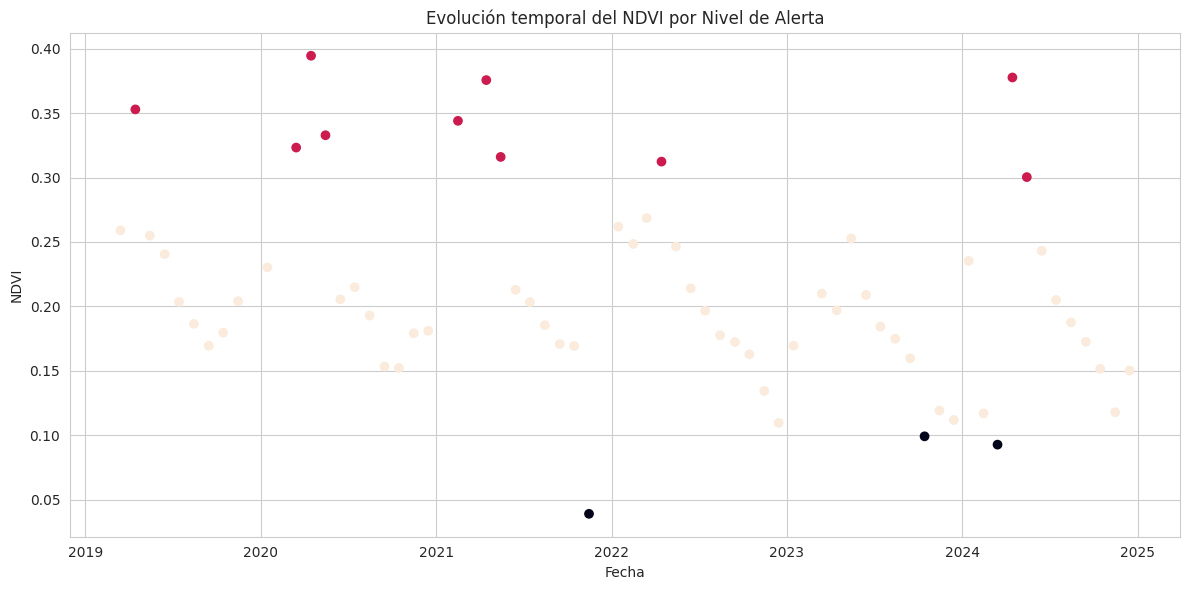

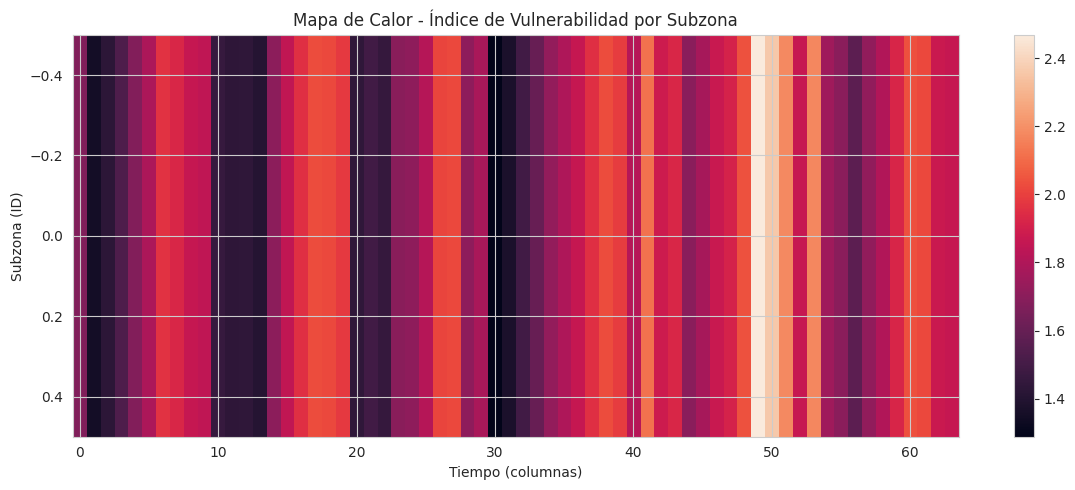

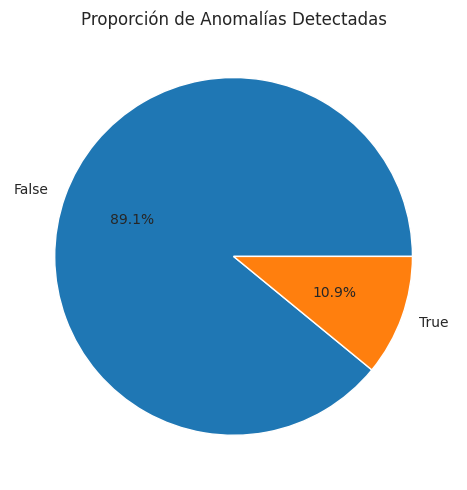

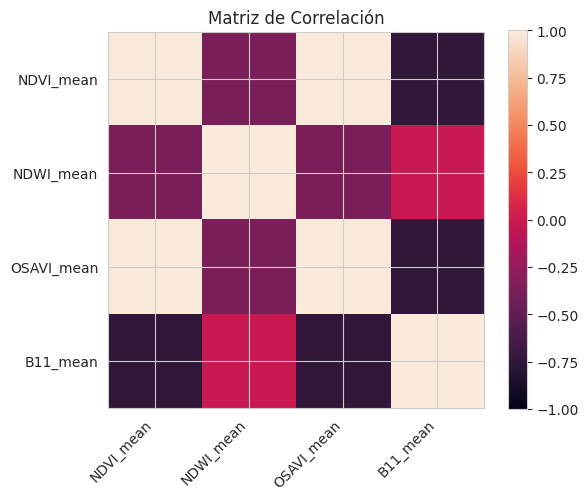

✅ Listo. Guardado: /content/Tambokarkas5_alerta_temprana_procesado.csv
Bandas estandarizadas usadas: ['NDVI_mean', 'NDWI_mean', 'OSAVI_mean', 'B11_mean']


In [ ]:
# ================================
# PROCESAMIENTO + ALERTA TEMPRANA
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from pathlib import Path

# --- 1) Cargar CSV ---
csv_path = Path("/content/Tambokarkas5_alerta_temprana_multibanda.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"No encuentro: {csv_path}. Sube el archivo a /content o corrige la ruta.")

df = pd.read_csv(csv_path)

# --- 2) Normalizar nombres de bandas: acepta con/sin sufijo _mean ---
# Mapeo flexible: si existe NDVI_mean usa ese; si no, intenta NDVI; igual para NDWI, OSAVI, B11, B12
def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

cols = set(df.columns)
band_map = {
    "NDVI_mean" : first_existing(cols, ["NDVI_mean", "NDVI"]),
    "NDWI_mean" : first_existing(cols, ["NDWI_mean", "NDWI"]),
    "OSAVI_mean": first_existing(cols, ["OSAVI_mean", "OSAVI"]),
    "B11_mean"  : first_existing(cols, ["B11_mean", "B11"]),
    "B12_mean"  : first_existing(cols, ["B12_mean", "B12"]),
}
# quitar las que no existan
band_map = {std: real for std, real in band_map.items() if real is not None}

# si no hay ninguna banda clave, abortar con mensaje claro
if not band_map:
    raise ValueError(f"No se encontraron columnas de bandas esperadas. "
                     f"Columnas disponibles: {sorted(df.columns)}")

# crear columnas estándar (copias) para trabajar homogéneamente
for std_name, real_name in band_map.items():
    df[std_name] = pd.to_numeric(df[real_name], errors="coerce")

print("Bandas detectadas y estandarizadas:", band_map)

# --- 3) Chequear y construir Fecha ---
required_time = {"year","month"}
if not required_time.issubset(df.columns):
    raise ValueError("El CSV debe tener columnas 'year' y 'month'.")

df["year"]  = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")
df = df.dropna(subset=["year","month"])
df["Fecha"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" +
                             df["month"].astype(int).astype(str) + "-15",
                             errors="coerce")
df = df.dropna(subset=["Fecha"])

# --- 4) ID (si no existe) ---
if "ID" not in df.columns:
    df["ID"] = 1

# --- 5) Conjunto de bandas finales a usar (las que sí se estandarizaron) ---
bands_std = [b for b in ["NDVI_mean","NDWI_mean","OSAVI_mean","B11_mean","B12_mean"] if b in df.columns]
if not bands_std:
    raise ValueError("No quedaron bandas estandarizadas para procesar.")

# ordenar temporalmente
df = df.sort_values(["ID","Fecha"]).reset_index(drop=True)

# --- 6) Estadísticas históricas por ID (mean/std) ---
stats = df.groupby("ID")[bands_std].agg(["mean","std"]).reset_index()
stats.columns = ["ID"] + [f"{b}_{suf}" for b in bands_std for suf in ["mean_hist","std_hist"]]
df = df.merge(stats, on="ID", how="left")

# --- 7) Z-scores por banda ---
for b in bands_std:
    std_col = f"{b}_std_hist"
    mean_col = f"{b}_mean_hist"
    df[std_col] = df[std_col].replace(0, 1e-6)
    df[f"{b}_z"] = (df[b] - df[mean_col]) / df[std_col]

# --- 8) Anomalías con IsolationForest (usa las bandas disponibles) ---
X = df[bands_std].apply(pd.to_numeric, errors="coerce").fillna(0.0)
iso = IsolationForest(contamination=0.1, random_state=42)
df["anom"] = iso.fit_predict(X)
df["Es_Anomalia"] = df["anom"] == -1

# --- 9) Reglas de alerta (usando NDVI/NDWI estandarizados si existen) ---
NDVIc = "NDVI_mean" if "NDVI_mean" in df.columns else None
NDWIc = "NDWI_mean" if "NDWI_mean" in df.columns else None

def alerta(row):
    ndvi = row.get(NDVIc, np.nan) if NDVIc else np.nan
    ndwi = row.get(NDWIc, np.nan) if NDWIc else np.nan
    es_anom = bool(row.get("Es_Anomalia", False))

    if pd.notna(ndvi) and ndvi < 0.10:
        return "🔴 Degradación Severa"
    if es_anom and pd.notna(ndvi) and ndvi < 0.20:
        return "🟠 Alerta Naranja (Anomalía)"
    if (pd.notna(ndwi) and ndwi < 0) and (pd.notna(ndvi) and ndvi < 0.30):
        return "🟡 Estrés Hídrico"
    if pd.notna(ndvi) and ndvi < 0.50:
        return "🔵 Condición Regular"
    return "🟢 Condición Buena"

df["Nivel_Alerta"] = df.apply(alerta, axis=1)

# --- 10) Índice de vulnerabilidad ---
b11c = "B11_mean" if "B11_mean" in df.columns else None
df["Indice_Vuln"] = (
    -(pd.to_numeric(df[NDVIc], errors="coerce").fillna(0) if NDVIc else 0) * 0.4
    -(pd.to_numeric(df[NDWIc], errors="coerce").fillna(0) if NDWIc else 0) * 0.3
    +(pd.to_numeric(df[b11c],  errors="coerce").fillna(0) if b11c else 0) * 0.0005
    + df["Es_Anomalia"].astype(int) * 0.2
)

# ==================
# 🚀 VISUALIZACIÓN
# ==================
# 1) NDVI vs tiempo por nivel de alerta (si existe NDVI)
if NDVIc:
    plt.figure(figsize=(12,6))
    cats = df["Nivel_Alerta"].astype("category")
    codes = cats.cat.codes
    plt.scatter(df["Fecha"], pd.to_numeric(df[NDVIc], errors="coerce"), c=codes)
    plt.title("Evolución temporal del NDVI por Nivel de Alerta")
    plt.xlabel("Fecha"); plt.ylabel("NDVI")
    plt.tight_layout()
    plt.show()
else:
    print("Aviso: No hay NDVI para graficar la evolución temporal.")

# 2) Heatmap del Índice de Vulnerabilidad
pv = df.pivot_table(index="ID", columns="Fecha", values="Indice_Vuln", aggfunc="mean")
plt.figure(figsize=(12,5))
plt.imshow(pv.fillna(0).to_numpy(), aspect="auto")
plt.title("Mapa de Calor - Índice de Vulnerabilidad por Subzona")
plt.xlabel("Tiempo (columnas)"); plt.ylabel("Subzona (ID)")
plt.colorbar()
plt.tight_layout()
plt.show()

# 3) Pie de anomalías
vals = df["Es_Anomalia"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(vals.values, labels=[str(k) for k in vals.index], autopct="%1.1f%%")
plt.title("Proporción de Anomalías Detectadas")
plt.tight_layout()
plt.show()

# 4) Matriz de correlación (solo con las bandas disponibles)
corr_cols = [c for c in ["NDVI_mean","NDWI_mean","OSAVI_mean","B11_mean","B12_mean"] if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr().to_numpy()
    plt.figure(figsize=(6,5))
    plt.imshow(corr, vmin=-1, vmax=1, aspect="equal")
    plt.title("Matriz de Correlación")
    plt.xticks(ticks=range(len(corr_cols)), labels=corr_cols, rotation=45, ha="right")
    plt.yticks(ticks=range(len(corr_cols)), labels=corr_cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Aviso: No hay suficientes bandas para la matriz de correlación.")

# Guardar procesado
out_csv = "/content/Tambokarkas5_alerta_temprana_procesado.csv"
df.to_csv(out_csv, index=False)
print("✅ Listo. Guardado:", out_csv)
print("Bandas estandarizadas usadas:", corr_cols or bands_std)


In [ ]:
# 1️⃣ Instalar librerías necesarias
#!pip install geemap matplotlib seaborn

# 2️⃣ Importar librerías
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 3️⃣ Inicializar Earth Engine (ya lo tienes hecho)
ee.Initialize(project='protean-harbor-447001-n6')

print("✅ Earth Engine inicializado correctamente")

# 4️⃣ Cargar área de estudio
shapefile = ee.FeatureCollection('projects/protean-harbor-447001-n6/assets/Tambokarkas5')
geom = shapefile.geometry()

# 5️⃣ Función para calcular índices de vegetación
def calcular_indices_vegetacion(image):
    # NDVI - Índice de Vegetación de Diferencia Normalizada
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # NDWI - Índice de Agua de Diferencia Normalizada
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    # EVI - Índice de Vegetación Mejorado
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')

    # MSAVI2 - Índice de Vegetación Ajustado al Suelo Modificado
    msavi2 = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI2')

    return image.addBands([ndvi, ndwi, evi, msavi2])

# 6️⃣ Función para aplicar máscara de nubes (Sentinel-2)
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask)

✅ Earth Engine inicializado correctamente


In [ ]:
# 7️⃣ Obtener datos históricos para establecer línea base
def obtener_datos_historicos(año_inicio, año_fin, mes_inicio, mes_fin):
    """Obtener datos históricos para establecer línea base de referencia"""

    coleccion_historica = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(geom) \
        .filterDate(f'{año_inicio}-{mes_inicio:02d}-01', f'{año_fin}-{mes_fin:02d}-28') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(maskS2clouds) \
        .map(calcular_indices_vegetacion)

    return coleccion_historica

# 8️⃣ Obtener datos actuales para monitoreo
def obtener_datos_actuales(año, mes):
    """Obtener datos del período actual para comparación"""

    fecha_inicio = f'{año}-{mes:02d}-01'
    fecha_fin = f'{año}-{mes:02d}-28'

    coleccion_actual = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(geom) \
        .filterDate(fecha_inicio, fecha_fin) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(maskS2clouds) \
        .map(calcular_indices_vegetacion)

    return coleccion_actual

In [ ]:
# 9️⃣ Función para detectar anomalías (degradación)
def detectar_degradacion(historico, actual, umbral_anomalia=-0.15):
    """
    Detectar áreas con degradación basado en desviación de índices
    umbral_anomalia: -0.15 significa 15% de reducción en vegetación
    """

    # Calcular mediana histórica de NDVI
    ndvi_historico_mediana = historico.select('NDVI').median()

    # Calcular mediana actual de NDVI
    ndvi_actual_mediana = actual.select('NDVI').median()

    # Calcular anomalía (diferencia porcentual)
    anomalia_ndvi = ndvi_actual_mediana.subtract(ndvi_historico_mediana) \
                        .divide(ndvi_historico_mediana) \
                        .rename('ANOMALIA_NDVI')

    # Identificar áreas degradadas (anomalía < umbral)
    areas_degradadas = anomalia_ndvi.lt(umbral_anomalia).rename('DEGRADACION')

    return areas_degradadas, anomalia_ndvi, ndvi_actual_mediana, ndvi_historico_mediana

# 🔟 Sistema de alerta temprana
def sistema_alerta_temprana():
    """Sistema principal de alerta temprana para degradación de pastizales"""

    print("🚀 Iniciando sistema de alerta temprana...")

    # Definir períodos (puedes ajustar estos parámetros)
    año_historico_inicio = 2019
    año_historico_fin = 2022
    año_actual = 2023
    mes_actual = 8  # Agosto como ejemplo

    print(f"📊 Obteniendo datos históricos ({año_historico_inicio}-{año_historico_fin})...")
    datos_historicos = obtener_datos_historicos(año_historico_inicio, año_historico_fin, 1, 12)

    print(f"📊 Obteniendo datos actuales ({año_actual}-{mes_actual:02d})...")
    datos_actuales = obtener_datos_actuales(año_actual, mes_actual)

    # Verificar que hay datos disponibles
    count_historico = datos_historicos.size().getInfo()
    count_actual = datos_actuales.size().getInfo()

    print(f"📈 Imágenes históricas disponibles: {count_historico}")
    print(f"📈 Imágenes actuales disponibles: {count_actual}")

    if count_actual == 0:
        print("⚠️ No hay datos actuales disponibles. Probando con datos de prueba...")
        # Usar datos históricos como prueba
        datos_actuales = obtener_datos_historicos(2022, 2022, mes_actual, mes_actual)
        count_actual = datos_actuales.size().getInfo()
        print(f"📈 Imágenes de prueba disponibles: {count_actual}")

    if count_actual == 0:
        print("❌ No hay datos suficientes para el análisis")
        return None

    print("🔍 Detectando áreas degradadas...")
    areas_degradadas, anomalia_ndvi, ndvi_actual, ndvi_historico = detectar_degradacion(
        datos_historicos, datos_actuales)

    # Calcular estadísticas
    stats_degradacion = areas_degradadas.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=10,
        maxPixels=1e9
    ).getInfo()

    porcentaje_degradacion = stats_degradacion.get('DEGRADACION', 0) * 100

    print(f"📊 Porcentaje de área degradada: {porcentaje_degradacion:.2f}%")

    # Determinar nivel de alerta
    if porcentaje_degradacion > 18:
        nivel_alerta = "🔴 ALERTA ROJA - Degradación severa"
    elif porcentaje_degradacion > 10:
        nivel_alerta = "🟡 ALERTA AMARILLA - Degradación moderada"
    elif porcentaje_degradacion > 5:
        nivel_alerta = "🟠 ALERTA NARANJA - Degradación leve"
    else:
        nivel_alerta = "🟢 SITUACIÓN NORMAL"

    print(f"🚨 {nivel_alerta}")

    return {
        'areas_degradadas': areas_degradadas,
        'anomalia_ndvi': anomalia_ndvi,
        'ndvi_actual': ndvi_actual,
        'ndvi_historico': ndvi_historico,
        'porcentaje_degradacion': porcentaje_degradacion,
        'nivel_alerta': nivel_alerta,
        'datos_actuales': datos_actuales,
        'datos_historicos': datos_historicos
    }

In [ ]:

# 1️⃣1️⃣ Visualización de resultados (CORREGIDA)
def visualizar_resultados(resultados):
    """Visualizar los resultados del sistema de alerta"""

    if resultados is None:
        print("❌ No hay resultados para visualizar")
        return

    # Crear mapa
    Map = geemap.Map()
    Map.centerObject(geom, 12)

    # Añadir área de estudio
    Map.addLayer(shapefile, {'color': 'blue', 'fillColor': '00000000'}, 'Área de estudio')

    # Añadir NDVI histórico
    Map.addLayer(resultados['ndvi_historico'].clip(geom),
                {'min': 0, 'max': 1, 'palette': ['red', 'yellow', 'green']},
                'NDVI Histórico (Línea base)')

    # Añadir NDVI actual
    Map.addLayer(resultados['ndvi_actual'].clip(geom),
                {'min': 0, 'max': 1, 'palette': ['red', 'yellow', 'green']},
                'NDVI Actual')

    # Añadir anomalías
    Map.addLayer(resultados['anomalia_ndvi'].clip(geom),
                {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'green']},
                'Anomalía NDVI')

    # Añadir áreas degradadas (en rojo)
    Map.addLayer(resultados['areas_degradadas'].clip(geom),
                {'min': 0, 'max': 1, 'palette': ['00FF00', 'FF0000']},
                f'Áreas Degradadas ({resultados["porcentaje_degradacion"]:.1f}%)')

    # CORRECCIÓN: Leyenda con formato correcto
    legend_dict = {
        'Área de estudio': '0000FF',
        'NDVI Alto (>0.6)': '008000',
        'NDVI Medio (0.35-0.6)': 'FFFF00',
        'NDVI Bajo (<0.35)': 'FF0000',
        'Degradación severa': '8B0000'
    }

    # Añadir leyenda corregida
    Map.add_legend(legend_title="Leyenda", legend_dict=legend_dict)

    # Mostrar alerta en el mapa usando un marcador en lugar de label
    alerta_texto = resultados['nivel_alerta']
    if "ROJA" in alerta_texto:
        Map.add_marker([geom.centroid().coordinates().get(1).getInfo(),
                       geom.centroid().coordinates().get(0).getInfo()],
                     popup=alerta_texto, icon='red')
    elif "AMARILLA" in alerta_texto:
        Map.add_marker([geom.centroid().coordinates().get(1).getInfo(),
                       geom.centroid().coordinates().get(0).getInfo()],
                     popup=alerta_texto, icon='orange')
    else:
        Map.add_marker([geom.centroid().coordinates().get(1).getInfo(),
                       geom.centroid().coordinates().get(0).getInfo()],
                     popup=alerta_texto, icon='green')

    print("🗺️ Mapa generado correctamente")
    return Map

# 1️⃣2️⃣ Generar reporte de degradación
def generar_reporte(resultados):
    """Generar un reporte detallado de la degradación"""

    if resultados is None:
        return

    print("\n" + "="*60)
    print("📋 REPORTE DE DEGRADACIÓN DE PASTIZALES")
    print("="*60)
    print(f"📍 Área de estudio: Tambokarkas5")
    print(f"📅 Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"📊 Porcentaje de área degradada: {resultados['porcentaje_degradacion']:.2f}%")
    print(f"🚨 Nivel de alerta: {resultados['nivel_alerta']}")
    print("\n📈 RECOMENDACIONES:")

    if resultados['porcentaje_degradacion'] > 20:
        print("   • Implementar medidas urgentes de restauración")
        print("   • Reducir carga animal inmediatamente")
        print("   • Considerar siembra de especies resistentes")
        print("   • Monitoreo semanal de la evolución")
    elif resultados['porcentaje_degradacion'] > 10:
        print("   • Reducir carga animal en áreas afectadas")
        print("   • Implementar rotación de pastoreo")
        print("   • Monitoreo mensual de la evolución")
    elif resultados['porcentaje_degradacion'] > 5:
        print("   • Ajustar manejo de pastoreo")
        print("   • Monitoreo trimestral")
        print("   • Considerar enmiendas orgánicas")
    else:
        print("   • Mantener prácticas actuales")
        print("   • Monitoreo semestral preventivo")

    print("="*60)

# 1️⃣3️⃣ Función alternativa para visualización simple
def visualizacion_simple(resultados):
    """Visualización alternativa más simple"""

    Map = geemap.Map()
    Map.centerObject(geom, 12)

    # Capa base
    Map.addLayer(shapefile, {'color': 'blue'}, 'Área de estudio')

    # Áreas degradadas
    Map.addLayer(resultados['areas_degradadas'].clip(geom),
                {'palette': ['green', 'red']},
                f'Degradación ({resultados["porcentaje_degradacion"]:.1f}%)')

    # NDVI actual para contexto
    Map.addLayer(resultados['ndvi_actual'].clip(geom),
                {'min': 0, 'max': 1, 'palette': ['brown', 'yellow', 'green']},
                'NDVI Actual')

    print(f"🚨 {resultados['nivel_alerta']}")
    return Map

# 1️⃣4️⃣ Ejecutar el sistema completo
if __name__ == "__main__":
    # Ejecutar sistema de alerta
    resultados = sistema_alerta_temprana()

    # Generar reporte
    generar_reporte(resultados)

    # Visualizar resultados
    if resultados:
        try:
            # Intentar visualización completa
            mapa = visualizar_resultados(resultados)
        except Exception as e:
            print(f"⚠️ Error en visualización completa: {e}")
            print("🔄 Usando visualización simple...")
            mapa = visualizacion_simple(resultados)

        if mapa:
            # Guardar mapa como HTML
            mapa.save('alerta_degradacion_pastizales.html')
            print("💾 Mapa guardado como 'alerta_degradacion_pastizales.html'")

            # Mostrar mapa en Colab
            display(mapa)
    else:
        print("❌ No se pudieron generar resultados")

# 1️⃣5️⃣ Análisis adicional con tus datos CSV
def analizar_datos_csv():
    """Analizar el archivo CSV que proporcionaste"""
    try:
        # Cargar datos CSV
        df = pd.read_csv('Tambokarkas5_alerta_temprana_multibanda.csv')

        print("📊 Análisis de datos CSV:")
        print(f"Registros en CSV: {len(df)}")
        print(f"Columnas: {df.columns.tolist()}")

        # Análisis de NDVI por mes
        if 'NDVI' in df.columns and 'month' in df.columns:
            ndvi_por_mes = df.groupby('month')['NDVI'].mean()
            print("\n📈 NDVI promedio por mes:")
            for mes, ndvi in ndvi_por_mes.items():
                print(f"  Mes {int(mes)}: {ndvi:.3f}")

        # Gráfico de NDVI
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        if 'NDVI' in df.columns and 'month' in df.columns:
            sns.boxplot(data=df, x='month', y='NDVI')
            plt.title('Distribución de NDVI por Mes')
            plt.xlabel('Mes')
            plt.ylabel('NDVI')

        plt.subplot(1, 2, 2)
        if 'NDVI' in df.columns and 'year' in df.columns:
            ndvi_por_año = df.groupby('year')['NDVI'].mean()
            ndvi_por_año.plot(kind='bar', color='green')
            plt.title('NDVI Promedio por Año')
            plt.xlabel('Año')
            plt.ylabel('NDVI Promedio')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Error al analizar CSV: {e}")

# Ejecutar análisis CSV si el archivo existe
try:
    analizar_datos_csv()
except:
    print("ℹ️ No se pudo analizar el archivo CSV")

🚀 Iniciando sistema de alerta temprana...
📊 Obteniendo datos históricos (2019-2022)...
📊 Obteniendo datos actuales (2023-08)...
📈 Imágenes históricas disponibles: 109
📈 Imágenes actuales disponibles: 5
🔍 Detectando áreas degradadas...
📊 Porcentaje de área degradada: 18.20%
🚨 🔴 ALERTA ROJA - Degradación severa

📋 REPORTE DE DEGRADACIÓN DE PASTIZALES
📍 Área de estudio: Tambokarkas5
📅 Fecha de análisis: 2025-10-28 06:07
📊 Porcentaje de área degradada: 18.20%
🚨 Nivel de alerta: 🔴 ALERTA ROJA - Degradación severa

📈 RECOMENDACIONES:
   • Reducir carga animal en áreas afectadas
   • Implementar rotación de pastoreo
   • Monitoreo mensual de la evolución
⚠️ Error en visualización completa: The 'popup' trait of a Marker instance expected a Widget or None, not the str '🔴 ALERTA ROJA - Degradación severa'.
🔄 Usando visualización simple...
🚨 🔴 ALERTA ROJA - Degradación severa
💾 Mapa guardado como 'alerta_degradacion_pastizales.html'


Map(center=[-14.521851984975061, -69.75810065988118], controls=(WidgetControl(options=['position', 'transparen…

❌ Error al analizar CSV: [Errno 2] No such file or directory: 'Tambokarkas5_alerta_temprana_multibanda.csv'


🌍 SISTEMA DE MONITOREO TEMPORAL DE DEGRADACIÓN
🚀 INICIANDO ANÁLISIS TEMPORAL COMPLETO...
📊 INICIANDO ANÁLISIS TEMPORAL DE DEGRADACIÓN...

🔍 Analizando año 2019...
   📈 Degradación 2019: 0.00%

🔍 Analizando año 2020...
   📈 Degradación 2020: 0.15%

🔍 Analizando año 2021...
   📈 Degradación 2021: 62.82%

🔍 Analizando año 2022...
   📈 Degradación 2022: 65.11%

🔍 Analizando año 2023...
   📈 Degradación 2023: 62.14%

🔍 Analizando año 2024...
   📈 Degradación 2024: 59.14%


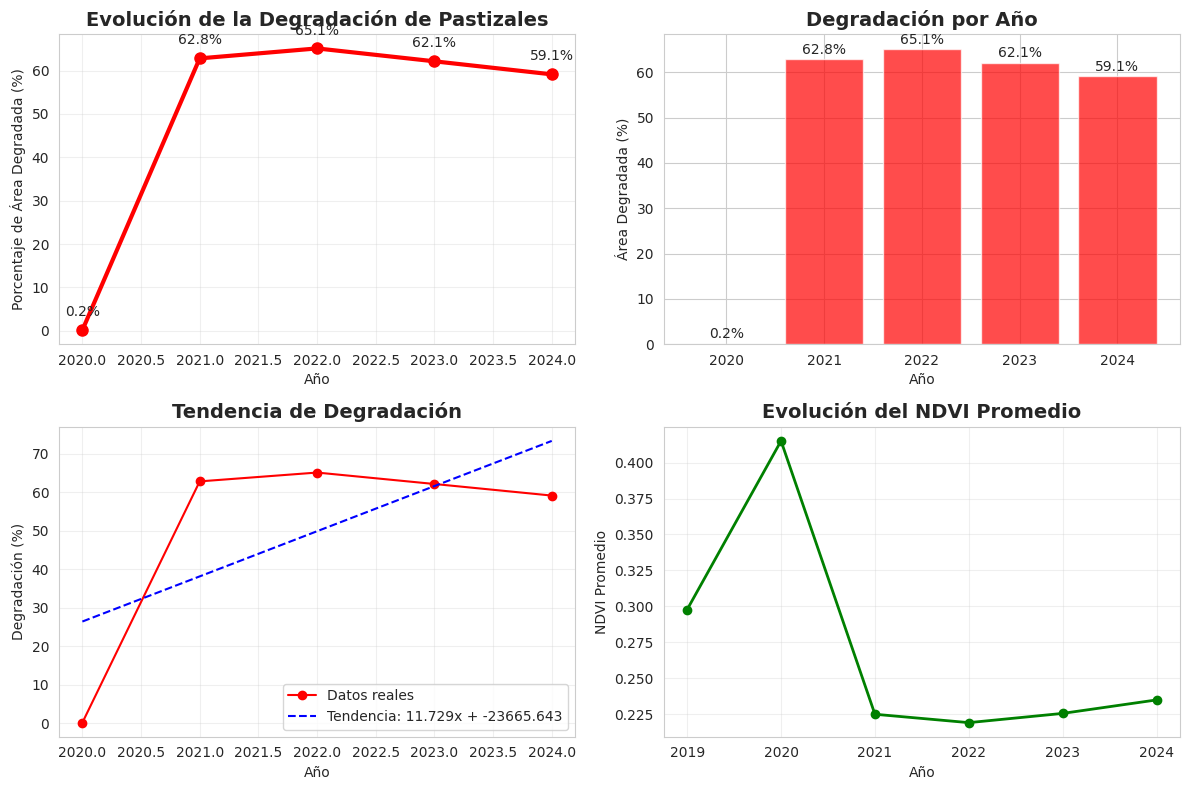


📈 RESUMEN EVOLUCIÓN TEMPORAL
2020: 0.15% degradado - ✅ MEJORÍA
2021: 62.82% degradado - 📈 AUMENTO
2022: 65.11% degradado - 📈 AUMENTO
2023: 62.14% degradado - 📈 AUMENTO
2024: 59.14% degradado - 📈 AUMENTO

🔍 Cambio total 2020-2024: +58.98% - Tendencia: ALARMANTE 📈

🗺️ GENERANDO MAPAS INTERACTIVOS...
💾 Mapa de evolución guardado como 'evolucion_degradacion_temporal.html'
💾 Mapa comparativo guardado como 'comparacion_2023_vs_2019.html'

📍 MAPA DE EVOLUCIÓN TEMPORAL (2019-2023):


Map(center=[-14.521851984975061, -69.75810065988118], controls=(WidgetControl(options=['position', 'transparen…


📍 MAPA COMPARATIVO (2023 vs 2019):


Map(center=[-14.521851984975061, -69.75810065988118], controls=(WidgetControl(options=['position', 'transparen…

⚠️ Error en análisis CSV: [Errno 2] No such file or directory: 'Tambokarkas5_alerta_temprana_multibanda.csv'

✅ ANÁLISIS TEMPORAL COMPLETADO
💡 Recomendación: Revisa los mapas HTML guardados para análisis detallado


In [ ]:
# SISTEMA DE VISUALIZACIÓN TEMPORAL PARA EVOLUCIÓN DE DEGRADACIÓN

def analisis_evolucion_temporal():
    """Analizar la evolución de la degradación año por año"""

    print("📊 INICIANDO ANÁLISIS TEMPORAL DE DEGRADACIÓN...")

    años = [2019, 2020, 2021, 2022, 2023,2024]
    resultados_anuales = {}

    for año in años:
        print(f"\n🔍 Analizando año {año}...")

        # Obtener datos del año específico
        datos_año = obtener_datos_historicos(año, año, 1, 12)
        count_imagenes = datos_año.size().getInfo()

        if count_imagenes > 0:
            # Usar 2019 como línea base para comparación
            if año == 2019:
                # Para 2019, comparar consigo mismo (línea base)
                areas_degradadas, anomalia_ndvi, ndvi_actual, ndvi_historico = detectar_degradacion(
                    datos_año, datos_año)
            else:
                # Para otros años, comparar con 2019
                datos_2019 = obtener_datos_historicos(2019, 2019, 1, 12)
                areas_degradadas, anomalia_ndvi, ndvi_actual, ndvi_historico = detectar_degradacion(
                    datos_2019, datos_año)

            # Calcular estadísticas
            stats_degradacion = areas_degradadas.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geom,
                scale=10,
                maxPixels=1e9
            ).getInfo()

            porcentaje_degradacion = stats_degradacion.get('DEGRADACION', 0) * 100

            resultados_anuales[año] = {
                'porcentaje_degradacion': porcentaje_degradacion,
                'ndvi_actual': ndvi_actual,
                'areas_degradadas': areas_degradadas,
                'imagenes_disponibles': count_imagenes
            }

            print(f"   📈 Degradación {año}: {porcentaje_degradacion:.2f}%")
        else:
            print(f"   ⚠️ No hay datos suficientes para {año}")

    return resultados_anuales

def crear_mapa_evolucion(resultados_anuales):
    """Crear mapa interactivo con la evolución temporal"""

    # Crear mapa base
    Map = geemap.Map()
    Map.centerObject(geom, 12)

    # Añadir área de estudio
    Map.addLayer(shapefile, {'color': 'blue', 'fillColor': '00000000'}, 'Área de estudio')

    # Capas por año
    for año, datos in resultados_anuales.items():
        if año in [2020, 2021, 2022, 2023,2024]:  # Excluir 2019 (línea base)
            # Añadir capa de degradación para cada año
            Map.addLayer(datos['areas_degradadas'].clip(geom),
                        {'min': 0, 'max': 1, 'palette': ['00FF00', 'FF0000']},
                        f'Degradación {año} ({datos["porcentaje_degradacion"]:.1f}%)')

            # Añadir capa de NDVI para cada año
            Map.addLayer(datos['ndvi_actual'].clip(geom),
                        {'min': 0, 'max': 1, 'palette': ['brown', 'yellow', 'green']},
                        f'NDVI {año}')

    # Leyenda mejorada
    legend_dict = {
        'Área de estudio': '0000FF',
        'NDVI Alto (>0.6)': '008000',
        'NDVI Medio (0.3-0.6)': 'FFFF00',
        'NDVI Bajo (<0.3)': 'FF0000',
        'Degradación 2020': 'FF6666',
        'Degradación 2021': 'FF3333',
        'Degradación 2022': 'FF0000',
        'Degradación 2023': 'CC0000'
    }

    Map.add_legend(legend_title="Evolución Temporal", legend_dict=legend_dict)

    return Map

def crear_mapa_comparativo_2023_vs_2019(resultados_anuales):
    """Mapa comparativo específico entre 2023 y línea base 2019"""

    Map = geemap.Map()
    Map.centerObject(geom, 12)

    # Capa base
    Map.addLayer(shapefile, {'color': 'blue', 'fillColor': '00000000'}, 'Área de estudio')

    # NDVI 2019 (Línea base)
    if 2019 in resultados_anuales:
        Map.addLayer(resultados_anuales[2019]['ndvi_actual'].clip(geom),
                    {'min': 0, 'max': 1, 'palette': ['brown', 'yellow', 'green']},
                    'NDVI 2019 (Línea Base)')

    # NDVI 2023 (Actual)
    if 2023 in resultados_anuales:
        Map.addLayer(resultados_anuales[2023]['ndvi_actual'].clip(geom),
                    {'min': 0, 'max': 1, 'palette': ['brown', 'yellow', 'green']},
                    'NDVI 2023 (Actual)')

    # Áreas degradadas 2023
    if 2023 in resultados_anuales:
        Map.addLayer(resultados_anuales[2023]['areas_degradadas'].clip(geom),
                    {'min': 0, 'max': 1, 'palette': ['00FF00', 'FF0000']},
                    f'Degradación 2023 ({resultados_anuales[2023]["porcentaje_degradacion"]:.1f}%)')

    # Leyenda comparativa
    legend_dict = {
        'Área de estudio': '0000FF',
        'NDVI 2019 (Base)': '00FF00',
        'NDVI 2023 (Actual)': '008000',
        'Áreas Degradadas 2023': 'FF0000'
    }

    Map.add_legend(legend_title="Comparación 2023 vs 2019", legend_dict=legend_dict)

    return Map

def generar_grafico_evolucion(resultados_anuales):
    """Generar gráfico de línea con la evolución de la degradación"""

    # Preparar datos para el gráfico
    años = []
    degradacion_porcentaje = []

    for año, datos in sorted(resultados_anuales.items()):
        if año != 2019:  # Excluir línea base
            años.append(año)
            degradacion_porcentaje.append(datos['porcentaje_degradacion'])

    # Crear gráfico
    plt.figure(figsize=(12, 8))

    # Gráfico de evolución
    plt.subplot(2, 2, 1)
    plt.plot(años, degradacion_porcentaje, 'ro-', linewidth=3, markersize=8)
    plt.title('Evolución de la Degradación de Pastizales', fontsize=14, fontweight='bold')
    plt.xlabel('Año')
    plt.ylabel('Porcentaje de Área Degradada (%)')
    plt.grid(True, alpha=0.3)

    # Añadir anotaciones
    for i, (año, valor) in enumerate(zip(años, degradacion_porcentaje)):
        plt.annotate(f'{valor:.1f}%', (año, valor),
                    textcoords="offset points", xytext=(0,10), ha='center')

    # Gráfico de barras
    plt.subplot(2, 2, 2)
    colores = ['green' if x < 5 else 'orange' if x < 10 else 'red' for x in degradacion_porcentaje]
    bars = plt.bar(años, degradacion_porcentaje, color=colores, alpha=0.7)
    plt.title('Degradación por Año', fontsize=14, fontweight='bold')
    plt.xlabel('Año')
    plt.ylabel('Área Degradada (%)')

    # Añadir valores en las barras
    for bar, valor in zip(bars, degradacion_porcentaje):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{valor:.1f}%', ha='center', va='bottom')

    # Gráfico de tendencia
    plt.subplot(2, 2, 3)
    if len(años) > 1:
        z = np.polyfit(años, degradacion_porcentaje, 1)
        p = np.poly1d(z)
        plt.plot(años, degradacion_porcentaje, 'ro-', label='Datos reales')
        plt.plot(años, p(años), 'b--', label=f'Tendencia: {z[0]:.3f}x + {z[1]:.3f}')
        plt.legend()
    plt.title('Tendencia de Degradación', fontsize=14, fontweight='bold')
    plt.xlabel('Año')
    plt.ylabel('Degradación (%)')
    plt.grid(True, alpha=0.3)

    # Gráfico de comparación con línea base
    plt.subplot(2, 2, 4)
    if 2019 in resultados_anuales:
        ndvi_2019 = resultados_anuales[2019]['ndvi_actual'].reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geom, scale=10).getInfo().get('NDVI', 0)

        ndvi_otros = []
        años_ndvi = []
        for año, datos in resultados_anuales.items():
            if año != 2019:
                ndvi = datos['ndvi_actual'].reduceRegion(
                    reducer=ee.Reducer.mean(), geometry=geom, scale=10).getInfo().get('NDVI', 0)
                ndvi_otros.append(ndvi)
                años_ndvi.append(año)

        plt.plot([2019] + años_ndvi, [ndvi_2019] + ndvi_otros, 'go-', linewidth=2)
        plt.title('Evolución del NDVI Promedio', fontsize=14, fontweight='bold')
        plt.xlabel('Año')
        plt.ylabel('NDVI Promedio')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Estadísticas resumen
    print("\n" + "="*60)
    print("📈 RESUMEN EVOLUCIÓN TEMPORAL")
    print("="*60)
    for año, datos in sorted(resultados_anuales.items()):
        if año != 2019:
            tendencia = "📈 AUMENTO" if datos['porcentaje_degradacion'] > 10 else "📉 ESTABLE" if datos['porcentaje_degradacion'] > 5 else "✅ MEJORÍA"
            print(f"{año}: {datos['porcentaje_degradacion']:.2f}% degradado - {tendencia}")

    if len(degradacion_porcentaje) > 1:
        cambio_total = degradacion_porcentaje[-1] - degradacion_porcentaje[0]
        tendencia_general = "ALARMANTE 📈" if cambio_total > 5 else "ESTABLE 📊" if cambio_total > 0 else "MEJORANDO 📉"
        print(f"\n🔍 Cambio total {años[0]}-{años[-1]}: {cambio_total:+.2f}% - Tendencia: {tendencia_general}")

def sistema_monitoreo_completo():
    """Sistema completo de monitoreo temporal"""

    print("🚀 INICIANDO ANÁLISIS TEMPORAL COMPLETO...")

    # 1. Análisis temporal
    resultados_anuales = analisis_evolucion_temporal()

    if not resultados_anuales:
        print("❌ No se pudieron obtener datos temporales")
        return

    # 2. Gráficos de evolución
    generar_grafico_evolucion(resultados_anuales)

    # 3. Mapas interactivos
    print("\n🗺️ GENERANDO MAPAS INTERACTIVOS...")

    # Mapa de evolución completa
    mapa_evolucion = crear_mapa_evolucion(resultados_anuales)
    mapa_evolucion.save('evolucion_degradacion_temporal.html')
    print("💾 Mapa de evolución guardado como 'evolucion_degradacion_temporal.html'")

    # Mapa comparativo
    mapa_comparativo = crear_mapa_comparativo_2023_vs_2019(resultados_anuales)
    mapa_comparativo.save('comparacion_2023_vs_2019.html')
    print("💾 Mapa comparativo guardado como 'comparacion_2023_vs_2019.html'")

    # Mostrar mapas
    print("\n📍 MAPA DE EVOLUCIÓN TEMPORAL (2019-2023):")
    display(mapa_evolucion)

    print("\n📍 MAPA COMPARATIVO (2023 vs 2019):")
    display(mapa_comparativo)

    return resultados_anuales

# EJECUTAR ANÁLISIS TEMPORAL COMPLETO
print("="*70)
print("🌍 SISTEMA DE MONITOREO TEMPORAL DE DEGRADACIÓN")
print("="*70)

resultados_temporales = sistema_monitoreo_completo()

# ANÁLISIS ADICIONAL CON TUS DATOS CSV
def analizar_tendencia_csv():
    """Analizar tendencia usando tu archivo CSV"""
    try:
        df = pd.read_csv('Tambokarkas5_alerta_temprana_multibanda.csv')

        print("\n📊 ANÁLISIS DE TENDENCIA CON DATOS CSV:")
        print("="*50)

        if 'NDVI' in df.columns and 'year' in df.columns and 'month' in df.columns:
            # NDVI promedio por año
            ndvi_por_año = df.groupby('year')['NDVI'].mean()
            print("\n📈 NDVI Promedio por Año:")
            for año, ndvi in ndvi_por_año.items():
                print(f"  {int(año)}: {ndvi:.3f}")

            # Gráfico de tendencia CSV
            plt.figure(figsize=(10, 6))
            ndvi_por_año.plot(kind='line', marker='o', linewidth=3, markersize=8)
            plt.title('Tendencia de NDVI (Datos CSV)', fontsize=14, fontweight='bold')
            plt.xlabel('Año')
            plt.ylabel('NDVI Promedio')
            plt.grid(True, alpha=0.3)
            plt.show()

    except Exception as e:
        print(f"⚠️ Error en análisis CSV: {e}")

# Ejecutar análisis CSV
analizar_tendencia_csv()

print("\n✅ ANÁLISIS TEMPORAL COMPLETADO")
print("💡 Recomendación: Revisa los mapas HTML guardados para análisis detallado")

In [ ]:
# ======================================================
# 🌍 EXPORTACIÓN DE MAPAS COMO GEO-TIFF
# ======================================================
def exportar_resultados_tiff(resultados, nombre_base='Tambokarkas5_alerta'):
    """Exporta los mapas clave a GeoTIFF desde Earth Engine"""

    if resultados is None:
        print("❌ No hay resultados para exportar")
        return

    print("💾 Iniciando exportación de mapas a GeoTIFF...")

    # Lista de mapas a exportar
    mapas_exportar = {
        'NDVI_Historico': resultados['ndvi_historico'],
        'NDVI_Actual': resultados['ndvi_actual'],
        'Anomalia_NDVI': resultados['anomalia_ndvi'],
        'Areas_Degradadas': resultados['areas_degradadas']
    }

    # Configuración general de exportación
    for nombre, imagen in mapas_exportar.items():
        descripcion = f"{nombre_base}_{nombre}"
        print(f"📤 Exportando {descripcion}.tif ...")

        tarea = ee.batch.Export.image.toDrive(
            image=imagen.clip(geom),
            description=descripcion,
            folder='GEE_Exports',        # cambia el nombre de carpeta si deseas
            fileNamePrefix=descripcion,
            region=geom.bounds().getInfo()['coordinates'],
            scale=10,
            maxPixels=1e13,
            fileFormat='GeoTIFF'
        )

        tarea.start()
        print(f"✅ Tarea iniciada en Google Drive: {descripcion}")

    print("📦 Exportaciones iniciadas. Verifica tu Google Drive (carpeta: GEE_Exports)")

# ======================================================
# 🔁 EJECUTAR EXPORTACIÓN (usa resultados del sistema)
# ======================================================
try:
    exportar_resultados_tiff(resultados)
except Exception as e:
    print(f"⚠️ Error durante exportación de TIFF: {e}")

💾 Iniciando exportación de mapas a GeoTIFF...
📤 Exportando Tambokarkas5_alerta_NDVI_Historico.tif ...
✅ Tarea iniciada en Google Drive: Tambokarkas5_alerta_NDVI_Historico
📤 Exportando Tambokarkas5_alerta_NDVI_Actual.tif ...
✅ Tarea iniciada en Google Drive: Tambokarkas5_alerta_NDVI_Actual
📤 Exportando Tambokarkas5_alerta_Anomalia_NDVI.tif ...
✅ Tarea iniciada en Google Drive: Tambokarkas5_alerta_Anomalia_NDVI
📤 Exportando Tambokarkas5_alerta_Areas_Degradadas.tif ...
✅ Tarea iniciada en Google Drive: Tambokarkas5_alerta_Areas_Degradadas
📦 Exportaciones iniciadas. Verifica tu Google Drive (carpeta: GEE_Exports)


# *Degradacion en Puno*

In [ ]:
# SISTEMA OPTIMIZADO PARA PUNO - SIN ERRORES DE SINTAXIS

# 1️⃣ Importar librerías
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Inicializar Earth Engine
ee.Initialize(project='protean-harbor-447001-n6')
print("✅ Earth Engine inicializado correctamente")

# 3️⃣ DEFINIR GEOMETRÍA DE PUNO CON ENFOQUE MÁS EFICIENTE
def obtener_geometria_puno_optimizada():
    """Obtener geometría de Puno con enfoque más eficiente en memoria"""

    # Usar bounding box más ajustado para reducir procesamiento
    print("📍 Cargando geometría optimizada de Puno...")
    coords_puno = [
        [-71.5, -17.5],  # Noroeste
        [-71.5, -13.5],  # Suroeste
        [-68.5, -13.5],  # Sureste
        [-68.5, -17.5],  # Noreste
        [-71.5, -17.5]   # Cerrar
    ]

    return ee.Geometry.Polygon(coords_puno)

# Obtener geometría optimizada
geom_puno = obtener_geometria_puno_optimizada()

# 4️⃣ Funciones básicas
def calcular_indices_vegetacion(image):
    """Calcular índices de vegetación"""
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

def maskS2clouds(image):
    """Máscara de nubes"""
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask)

def obtener_datos_por_año(año):
    """Obtener datos por año"""
    print(f"📊 Procesando año {año}...")
    fecha_inicio = f'{año}-05-01'
    fecha_fin = f'{año}-09-30'

    coleccion = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    coleccion = coleccion.filterBounds(geom_puno)
    coleccion = coleccion.filterDate(fecha_inicio, fecha_fin)
    coleccion = coleccion.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    coleccion = coleccion.map(maskS2clouds)
    coleccion = coleccion.map(calcular_indices_vegetacion)

    return coleccion

# 5️⃣ Análisis de degradación anual CORREGIDO
def analizar_degradacion_anual():
    """Analizar degradación anual comparando con línea base 2019"""

    print("📊 ANALIZANDO DEGRADACIÓN ANUAL 2019-2024")

    años = [2019, 2020, 2021, 2022, 2023, 2024]
    resultados_anuales = {}

    # Obtener línea base (2019)
    print("🔄 Cargando línea base 2019...")
    datos_2019 = obtener_datos_por_año(2019)
    ndvi_2019 = datos_2019.select('NDVI').median()

    for año in años:
        print(f"\n🔍 Analizando {año}...")

        try:
            if año == 2019:
                # Para 2019, no hay degradación (es la línea base)
                areas_degradadas = ee.Image(0).rename('DEGRADACION')
                porcentaje_degradacion = 0.0
                ndvi_actual = ndvi_2019
            else:
                # Para otros años, comparar con 2019
                datos_año = obtener_datos_por_año(año)
                ndvi_actual = datos_año.select('NDVI').median()

                # Calcular anomalía
                anomalia_ndvi = ndvi_actual.subtract(ndvi_2019).divide(ndvi_2019).rename('ANOMALIA_NDVI')

                # Identificar áreas degradadas (anomalía < -15%)
                areas_degradadas = anomalia_ndvi.lt(-0.15).rename('DEGRADACION')

                # Calcular porcentaje de degradación
                stats = areas_degradadas.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=geom_puno,
                    scale=1000,
                    maxPixels=1e8,
                    bestEffort=True
                ).getInfo()

                porcentaje_degradacion = stats.get('DEGRADACION', 0) * 100

            # Calcular NDVI promedio
            stats_ndvi = ndvi_actual.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geom_puno,
                scale=1000,
                maxPixels=1e8,
                bestEffort=True
            ).getInfo()

            ndvi_promedio = stats_ndvi.get('NDVI', 0)

            resultados_anuales[año] = {
                'porcentaje_degradacion': porcentaje_degradacion,
                'ndvi_promedio': ndvi_promedio,
                'areas_degradadas': areas_degradadas,
                'ndvi_actual': ndvi_actual,
                'imagenes': datos_año.size().getInfo() if año != 2019 else datos_2019.size().getInfo()
            }

            print(f"   ✅ Degradación: {porcentaje_degradacion:.1f}% | NDVI: {ndvi_promedio:.3f}")

        except Exception as e:
            print(f"   ❌ Error en {año}: {e}")
            continue

    return resultados_anuales


✅ Earth Engine inicializado correctamente
📍 Cargando geometría optimizada de Puno...


🌄 SISTEMA DE MONITOREO - PUNO 2019-2024
🗺️ CON MAPAS DE EVOLUCIÓN ANUAL

1️⃣ ANÁLISIS DE DEGRADACIÓN ANUAL
📊 ANALIZANDO DEGRADACIÓN ANUAL 2019-2024
🔄 Cargando línea base 2019...
📊 Procesando año 2019...

🔍 Analizando 2019...
   ✅ Degradación: 0.0% | NDVI: 0.271

🔍 Analizando 2020...
📊 Procesando año 2020...
   ✅ Degradación: 9.7% | NDVI: 0.293

🔍 Analizando 2021...
📊 Procesando año 2021...
   ✅ Degradación: 24.5% | NDVI: 0.241

🔍 Analizando 2022...
📊 Procesando año 2022...
   ✅ Degradación: 26.2% | NDVI: 0.243

🔍 Analizando 2023...
📊 Procesando año 2023...
   ✅ Degradación: 20.6% | NDVI: 0.245

🔍 Analizando 2024...
📊 Procesando año 2024...
   ✅ Degradación: 17.9% | NDVI: 0.252

2️⃣ GRÁFICOS DE EVOLUCIÓN
📈 GENERANDO GRÁFICOS DE EVOLUCIÓN...


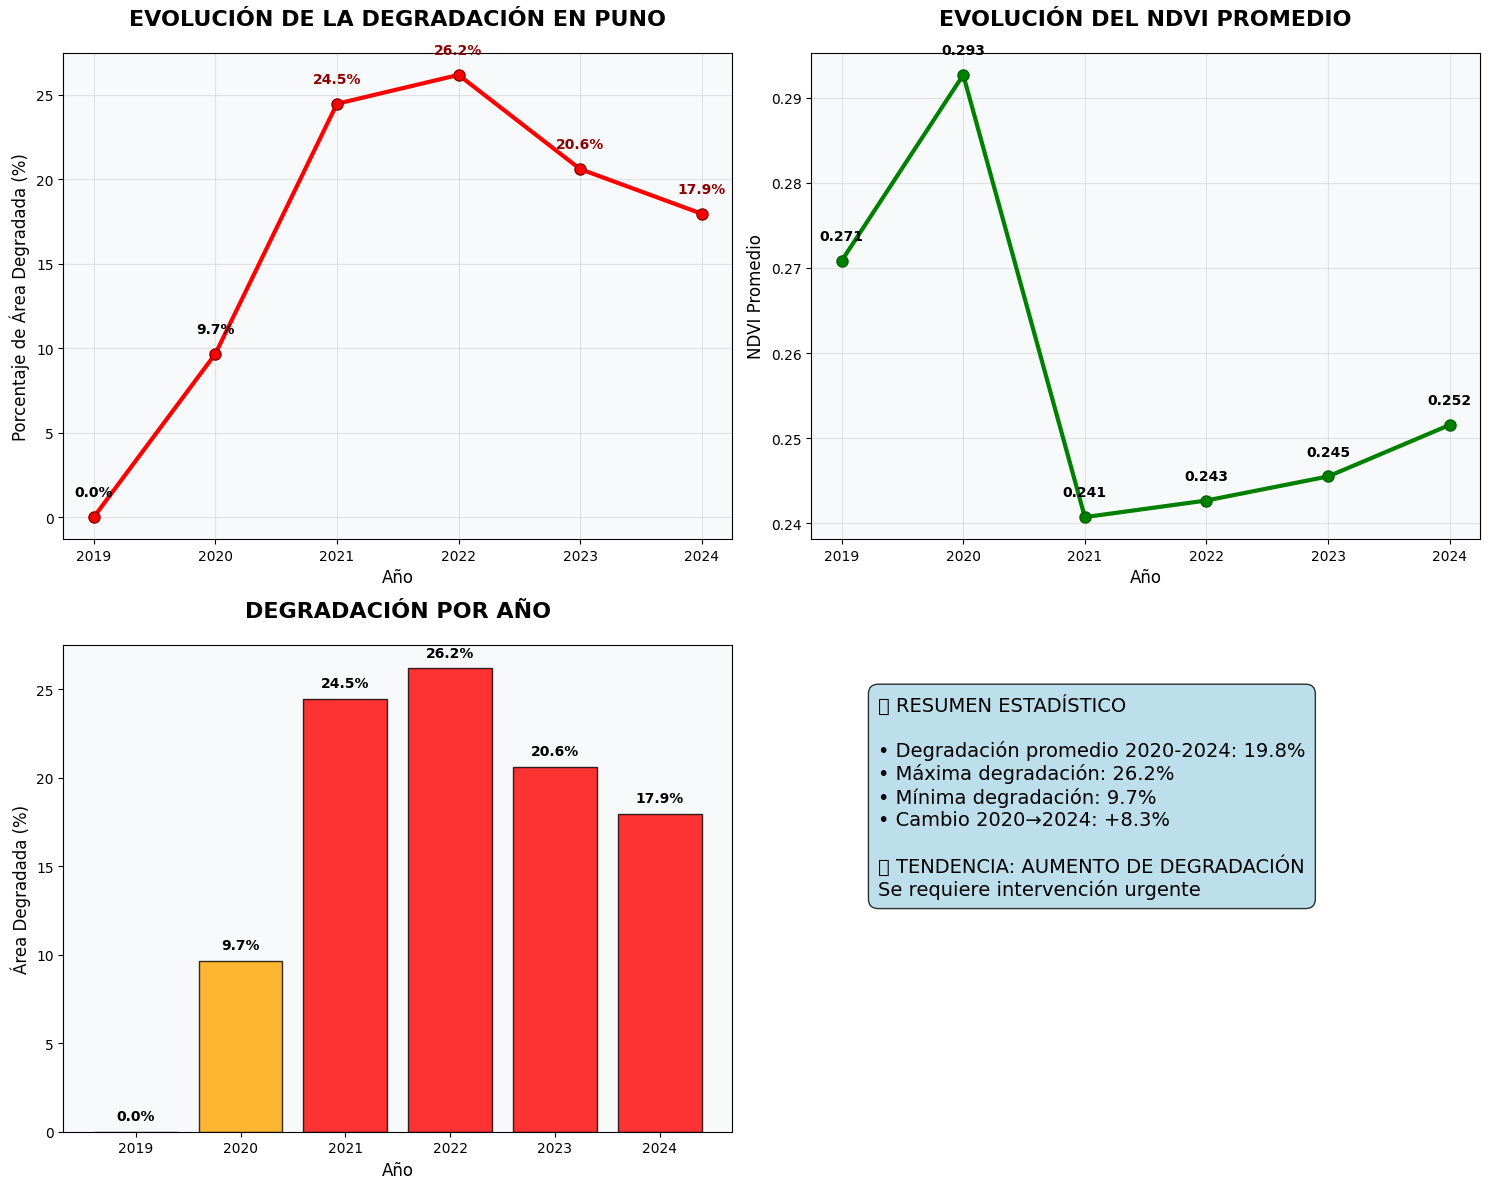


📋 TABLA RESUMEN DE DEGRADACIÓN
Año      Degradación (%) NDVI       Tendencia 
--------------------------------------------------
2019     0.0             0.271                
2020     9.7             0.293      +9.7%     
2021     24.5            0.241      +14.8%    
2022     26.2            0.243      +1.7%     
2023     20.6            0.245      -5.6%     
2024     17.9            0.252      -2.6%     

3️⃣ MAPAS DE EVOLUCIÓN ANUAL
🗺️ GENERANDO MAPA DE EVOLUCIÓN ANUAL...
💾 Mapa guardado: 'evolucion_degradacion_puno_2019_2024.html'
📍 Mostrando mapa interactivo...


Map(center=[-15.498590161986112, -70.00000000000007], controls=(WidgetControl(options=['position', 'transparen…


4️⃣ REPORTE FINAL
📋 EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO
2019: LÍNEA BASE | NDVI: 0.271
2020: 9.7% degradado 🟢 | NDVI: 0.293
2021: 24.5% degradado 🔴 | NDVI: 0.241
2022: 26.2% degradado 🔴 | NDVI: 0.243
2023: 20.6% degradado 🔴 | NDVI: 0.245
2024: 17.9% degradado 🟡 | NDVI: 0.252

🚨 SITUACIÓN 2024: 17.9% DE DEGRADACIÓN
   • ALERTA AMARILLA: Degradación moderada
   • Acciones prioritarias necesarias

✅ ANÁLISIS COMPLETADO EXITOSAMENTE


In [ ]:
# 6️⃣ Crear mapa de evolución anual CORREGIDO (sin marcadores problemáticos)
def crear_mapa_evolucion_anual(resultados_anuales):
    """Crear mapa con la evolución anual de la degradación"""

    print("🗺️ GENERANDO MAPA DE EVOLUCIÓN ANUAL...")

    Map = geemap.Map()
    Map.centerObject(geom_puno, 8)

    # Capa base de Puno
    Map.addLayer(geom_puno, {'color': 'blue', 'fillColor': '00000000'}, 'Departamento de Puno')

    # Añadir capas de degradación por año (CORREGIDO)
    colores_años = {
        2020: 'FF9999',  # Rojo claro
        2021: 'FF6666',  # Rojo medio
        2022: 'FF3333',  # Rojo
        2023: 'FF0000',  # Rojo intenso
        2024: 'CC0000'   # Rojo oscuro
    }

    for año, datos in resultados_anuales.items():
        if año != 2019:  # No mostrar 2019 (línea base)
            try:
                areas_degradadas = datos['areas_degradadas']

                # Asegurar proyección correcta
                areas_degradadas = areas_degradadas.setDefaultProjection(
                    crs='EPSG:4326',
                    scale=1000
                )

                # Añadir al mapa
                color = colores_años.get(año, 'FF0000')
                Map.addLayer(areas_degradadas.clip(geom_puno),
                            {'min': 0, 'max': 1, 'palette': ['00FF00', color]},
                            f'Degradación {año} ({datos["porcentaje_degradacion"]:.1f}%)')

            except Exception as e:
                print(f"⚠️ No se pudo cargar capa {año}: {e}")

    # Leyenda mejorada
    legend_dict = {
        'Límite Puno': '0000FF',
        'Degradación 2020': 'FF9999',
        'Degradación 2021': 'FF6666',
        'Degradación 2022': 'FF3333',
        'Degradación 2023': 'FF0000',
        'Degradación 2024': 'CC0000',
        'Áreas sin degradación': '00FF00'
    }

    Map.add_legend(legend_title="Evolución de la Degradación 2020-2024", legend_dict=legend_dict)

    # Añadir título usando HTML en lugar de marcadores problemáticos
    title_html = '''
    <div style="position: fixed;
                top: 10px; left: 50px; width: 300px; height: 100px;
                background-color: white; border:2px solid grey; z-index:9999;
                padding: 10px; border-radius: 5px;">
        <h4 style="margin:0; color:darkblue;">🌄 PUNO 2020-2024</h4>
        <p style="margin:5px 0; font-size:12px;">Evolución de la Degradación de Pastizales</p>
    </div>
    '''
    Map.add_html(title_html)

    return Map

# 7️⃣ Generar gráficos de evolución
def generar_graficos_evolucion(resultados_anuales):
    """Generar gráficos de evolución de la degradación"""

    print("📈 GENERANDO GRÁFICOS DE EVOLUCIÓN...")

    # Preparar datos
    años = []
    degradacion = []
    ndvi_valores = []

    for año, datos in sorted(resultados_anuales.items()):
        años.append(año)
        degradacion.append(datos['porcentaje_degradacion'])
        ndvi_valores.append(datos['ndvi_promedio'])

    # Crear gráficos
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Gráfico 1: Evolución de la degradación
    ax1.plot(años, degradacion, 'ro-', linewidth=3, markersize=8, markerfacecolor='red', markeredgecolor='darkred')
    ax1.set_title('EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Año', fontsize=12)
    ax1.set_ylabel('Porcentaje de Área Degradada (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor('#f8f9fa')

    # Añadir anotaciones
    for i, (año, valor) in enumerate(zip(años, degradacion)):
        color = 'darkred' if valor > 15 else 'black'
        ax1.annotate(f'{valor:.1f}%', (año, valor),
                    textcoords="offset points", xytext=(0,15),
                    ha='center', fontweight='bold', color=color, fontsize=10)

    # Gráfico 2: NDVI promedio
    ax2.plot(años, ndvi_valores, 'go-', linewidth=3, markersize=8, markerfacecolor='green', markeredgecolor='darkgreen')
    ax2.set_title('EVOLUCIÓN DEL NDVI PROMEDIO', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Año', fontsize=12)
    ax2.set_ylabel('NDVI Promedio', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

    # Añadir anotaciones NDVI
    for i, (año, valor) in enumerate(zip(años, ndvi_valores)):
        ax2.annotate(f'{valor:.3f}', (año, valor),
                    textcoords="offset points", xytext=(0,15),
                    ha='center', fontweight='bold', fontsize=10)

    # Gráfico 3: Barras de degradación
    colores_barras = ['green' if x < 5 else 'orange' if x < 15 else 'red' for x in degradacion]
    bars = ax3.bar(años, degradacion, color=colores_barras, alpha=0.8, edgecolor='black')
    ax3.set_title('DEGRADACIÓN POR AÑO', fontsize=16, fontweight='bold', pad=20)
    ax3.set_xlabel('Año', fontsize=12)
    ax3.set_ylabel('Área Degradada (%)', fontsize=12)
    ax3.set_facecolor('#f8f9fa')

    # Añadir valores en barras
    for bar, valor in zip(bars, degradacion):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Gráfico 4: Resumen estadístico
    ax4.axis('off')

    # Calcular estadísticas
    degradacion_sin_2019 = [degradacion[i] for i in range(1, len(degradacion))]
    cambio_total = degradacion[-1] - degradacion[1]  # Cambio desde 2020 a 2024

    resumen_text = "📊 RESUMEN ESTADÍSTICO\n\n"
    resumen_text += f"• Degradación promedio 2020-2024: {np.mean(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Máxima degradación: {max(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Mínima degradación: {min(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Cambio 2020→2024: {cambio_total:+.1f}%\n\n"

    # Análisis de tendencia
    if cambio_total > 5:
        resumen_text += "🚨 TENDENCIA: AUMENTO DE DEGRADACIÓN\n"
        resumen_text += "Se requiere intervención urgente"
    elif cambio_total < -2:
        resumen_text += "✅ TENDENCIA: MEJORÍA\n"
        resumen_text += "Las medidas están funcionando"
    else:
        resumen_text += "📊 TENDENCIA: ESTABLE\n"
        resumen_text += "Mantener monitoreo"

    ax4.text(0.1, 0.9, resumen_text, fontsize=14, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
            transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

    # Mostrar tabla resumen
    print("\n📋 TABLA RESUMEN DE DEGRADACIÓN")
    print("="*50)
    print(f"{'Año':<8} {'Degradación (%)':<15} {'NDVI':<10} {'Tendencia':<10}")
    print("-"*50)
    for i, año in enumerate(años):
        tendencia = ""
        if i > 0:
            cambio = degradacion[i] - degradacion[i-1]
            tendencia = f"{cambio:+.1f}%"
        print(f"{año:<8} {degradacion[i]:<15.1f} {ndvi_valores[i]:<10.3f} {tendencia:<10}")

# 8️⃣ Sistema completo CORREGIDO
def sistema_completo_corregido():
    """Sistema completo con mapas de evolución anual"""

    print("🌄 SISTEMA DE MONITOREO - PUNO 2019-2024")
    print("🗺️ CON MAPAS DE EVOLUCIÓN ANUAL")
    print("="*60)

    # 1. Análisis de degradación anual
    print("\n1️⃣ ANÁLISIS DE DEGRADACIÓN ANUAL")
    resultados_anuales = analizar_degradacion_anual()

    if not resultados_anuales:
        print("❌ No se pudieron obtener resultados")
        return

    # 2. Gráficos de evolución
    print("\n2️⃣ GRÁFICOS DE EVOLUCIÓN")
    generar_graficos_evolucion(resultados_anuales)

    # 3. Mapas de evolución
    print("\n3️⃣ MAPAS DE EVOLUCIÓN ANUAL")
    mapa_evolucion = crear_mapa_evolucion_anual(resultados_anuales)

    if mapa_evolucion:
        # Guardar mapa
        mapa_evolucion.save('evolucion_degradacion_puno_2019_2024.html')
        print("💾 Mapa guardado: 'evolucion_degradacion_puno_2019_2024.html'")

        # Mostrar mapa
        print("📍 Mostrando mapa interactivo...")
        display(mapa_evolucion)
    else:
        print("❌ No se pudo generar el mapa")

    # 4. Reporte final
    print("\n4️⃣ REPORTE FINAL")
    print("="*50)
    print("📋 EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO")
    print("="*50)

    for año, datos in sorted(resultados_anuales.items()):
        if año == 2019:
            print(f"{año}: LÍNEA BASE | NDVI: {datos['ndvi_promedio']:.3f}")
        else:
            alerta = "🔴" if datos['porcentaje_degradacion'] > 20 else "🟡" if datos['porcentaje_degradacion'] > 10 else "🟢"
            print(f"{año}: {datos['porcentaje_degradacion']:.1f}% degradado {alerta} | NDVI: {datos['ndvi_promedio']:.3f}")

    # Análisis de la situación 2024
    if 2024 in resultados_anuales:
        degradacion_2024 = resultados_anuales[2024]['porcentaje_degradacion']
        print(f"\n🚨 SITUACIÓN 2024: {degradacion_2024:.1f}% DE DEGRADACIÓN")

        if degradacion_2024 > 20:
            print("   • ALERTA ROJA: Degradación severa")
            print("   • Se requieren medidas urgentes")
        elif degradacion_2024 > 10:
            print("   • ALERTA AMARILLA: Degradación moderada")
            print("   • Acciones prioritarias necesarias")
        else:
            print("   • SITUACIÓN CONTROLADA")
            print("   • Mantener monitoreo")

    print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")

# EJECUTAR SISTEMA CORREGIDO
if __name__ == "__main__":
    sistema_completo_corregido()

In [ ]:
# SISTEMA OPTIMIZADO PARA PUNO - SIN ERRORES DE SINTAXIS

# 1️⃣ Importar librerías
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Inicializar Earth Engine
ee.Initialize(project='protean-harbor-447001-n6')
print("✅ Earth Engine inicializado correctamente")

# 2️⃣ GEOMETRÍA REAL DEL DEPARTAMENTO DE PUNO
# =========================================================

def obtener_geometria_puno_optimizada():
    """
    Obtiene la geometría real del Departamento de Puno
    usando los límites administrativos del FAO GAUL (simplificados).
    """
    print("📍 Cargando geometría real del Departamento de Puno...")

    gadm_peru = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level1") \
        .filter(ee.Filter.eq('ADM0_NAME', 'Peru'))

    puno = gadm_peru.filter(ee.Filter.eq('ADM1_NAME', 'Puno')).first()
    geom_puno = puno.geometry()

    print("✅ Geometría de Puno cargada correctamente.")
    return geom_puno

geom_puno = obtener_geometria_puno_optimizada()


# 4️⃣ Funciones básicas
def calcular_indices_vegetacion(image):
    """Calcular índices de vegetación"""
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

def maskS2clouds(image):
    """Máscara de nubes"""
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask)

def obtener_datos_por_año(año):
    """Obtener datos por año"""
    print(f"📊 Procesando año {año}...")
    fecha_inicio = f'{año}-05-01'
    fecha_fin = f'{año}-09-30'

    coleccion = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    coleccion = coleccion.filterBounds(geom_puno)
    coleccion = coleccion.filterDate(fecha_inicio, fecha_fin)
    coleccion = coleccion.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    coleccion = coleccion.map(maskS2clouds)
    coleccion = coleccion.map(calcular_indices_vegetacion)

    return coleccion

# 5️⃣ Análisis de degradación anual CORREGIDO
def analizar_degradacion_anual():
    """Analizar degradación anual comparando con línea base 2019"""

    print("📊 ANALIZANDO DEGRADACIÓN ANUAL 2019-2024")

    años = [2019, 2020, 2021, 2022, 2023, 2024]
    resultados_anuales = {}

    # Obtener línea base (2019)
    print("🔄 Cargando línea base 2019...")
    datos_2019 = obtener_datos_por_año(2019)
    ndvi_2019 = datos_2019.select('NDVI').median()

    for año in años:
        print(f"\n🔍 Analizando {año}...")

        try:
            if año == 2019:
                # Para 2019, no hay degradación (es la línea base)
                areas_degradadas = ee.Image(0).rename('DEGRADACION')
                porcentaje_degradacion = 0.0
                ndvi_actual = ndvi_2019
            else:
                # Para otros años, comparar con 2019
                datos_año = obtener_datos_por_año(año)
                ndvi_actual = datos_año.select('NDVI').median()

                # Calcular anomalía
                anomalia_ndvi = ndvi_actual.subtract(ndvi_2019).divide(ndvi_2019).rename('ANOMALIA_NDVI')

                # Identificar áreas degradadas (anomalía < -15%)
                areas_degradadas = anomalia_ndvi.lt(-0.15).rename('DEGRADACION')

                # Calcular porcentaje de degradación
                stats = areas_degradadas.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=geom_puno,
                    scale=1000,
                    maxPixels=1e8,
                    bestEffort=True
                ).getInfo()

                porcentaje_degradacion = stats.get('DEGRADACION', 0) * 100

            # Calcular NDVI promedio
            stats_ndvi = ndvi_actual.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geom_puno,
                scale=1000,
                maxPixels=1e8,
                bestEffort=True
            ).getInfo()

            ndvi_promedio = stats_ndvi.get('NDVI', 0)

            resultados_anuales[año] = {
                'porcentaje_degradacion': porcentaje_degradacion,
                'ndvi_promedio': ndvi_promedio,
                'areas_degradadas': areas_degradadas,
                'ndvi_actual': ndvi_actual,
                'imagenes': datos_año.size().getInfo() if año != 2019 else datos_2019.size().getInfo()
            }

            print(f"   ✅ Degradación: {porcentaje_degradacion:.1f}% | NDVI: {ndvi_promedio:.3f}")

        except Exception as e:
            print(f"   ❌ Error en {año}: {e}")
            continue

    return resultados_anuales

✅ Earth Engine inicializado correctamente
📍 Cargando geometría real del Departamento de Puno...
✅ Geometría de Puno cargada correctamente.


🌄 SISTEMA DE MONITOREO - PUNO 2019-2024
🗺️ CON MAPAS DE EVOLUCIÓN ANUAL

1️⃣ ANÁLISIS DE DEGRADACIÓN ANUAL
📊 ANALIZANDO DEGRADACIÓN ANUAL 2019-2024
🔄 Cargando línea base 2019...
📊 Procesando año 2019...

🔍 Analizando 2019...
   ✅ Degradación: 0.0% | NDVI: 0.329

🔍 Analizando 2020...
📊 Procesando año 2020...
   ✅ Degradación: 10.2% | NDVI: 0.358

🔍 Analizando 2021...
📊 Procesando año 2021...
   ✅ Degradación: 18.8% | NDVI: 0.294

🔍 Analizando 2022...
📊 Procesando año 2022...
   ✅ Degradación: 21.4% | NDVI: 0.301

🔍 Analizando 2023...
📊 Procesando año 2023...
   ✅ Degradación: 20.6% | NDVI: 0.303

🔍 Analizando 2024...
📊 Procesando año 2024...
   ✅ Degradación: 16.0% | NDVI: 0.310

2️⃣ GRÁFICOS DE EVOLUCIÓN
📈 GENERANDO GRÁFICOS DE EVOLUCIÓN...


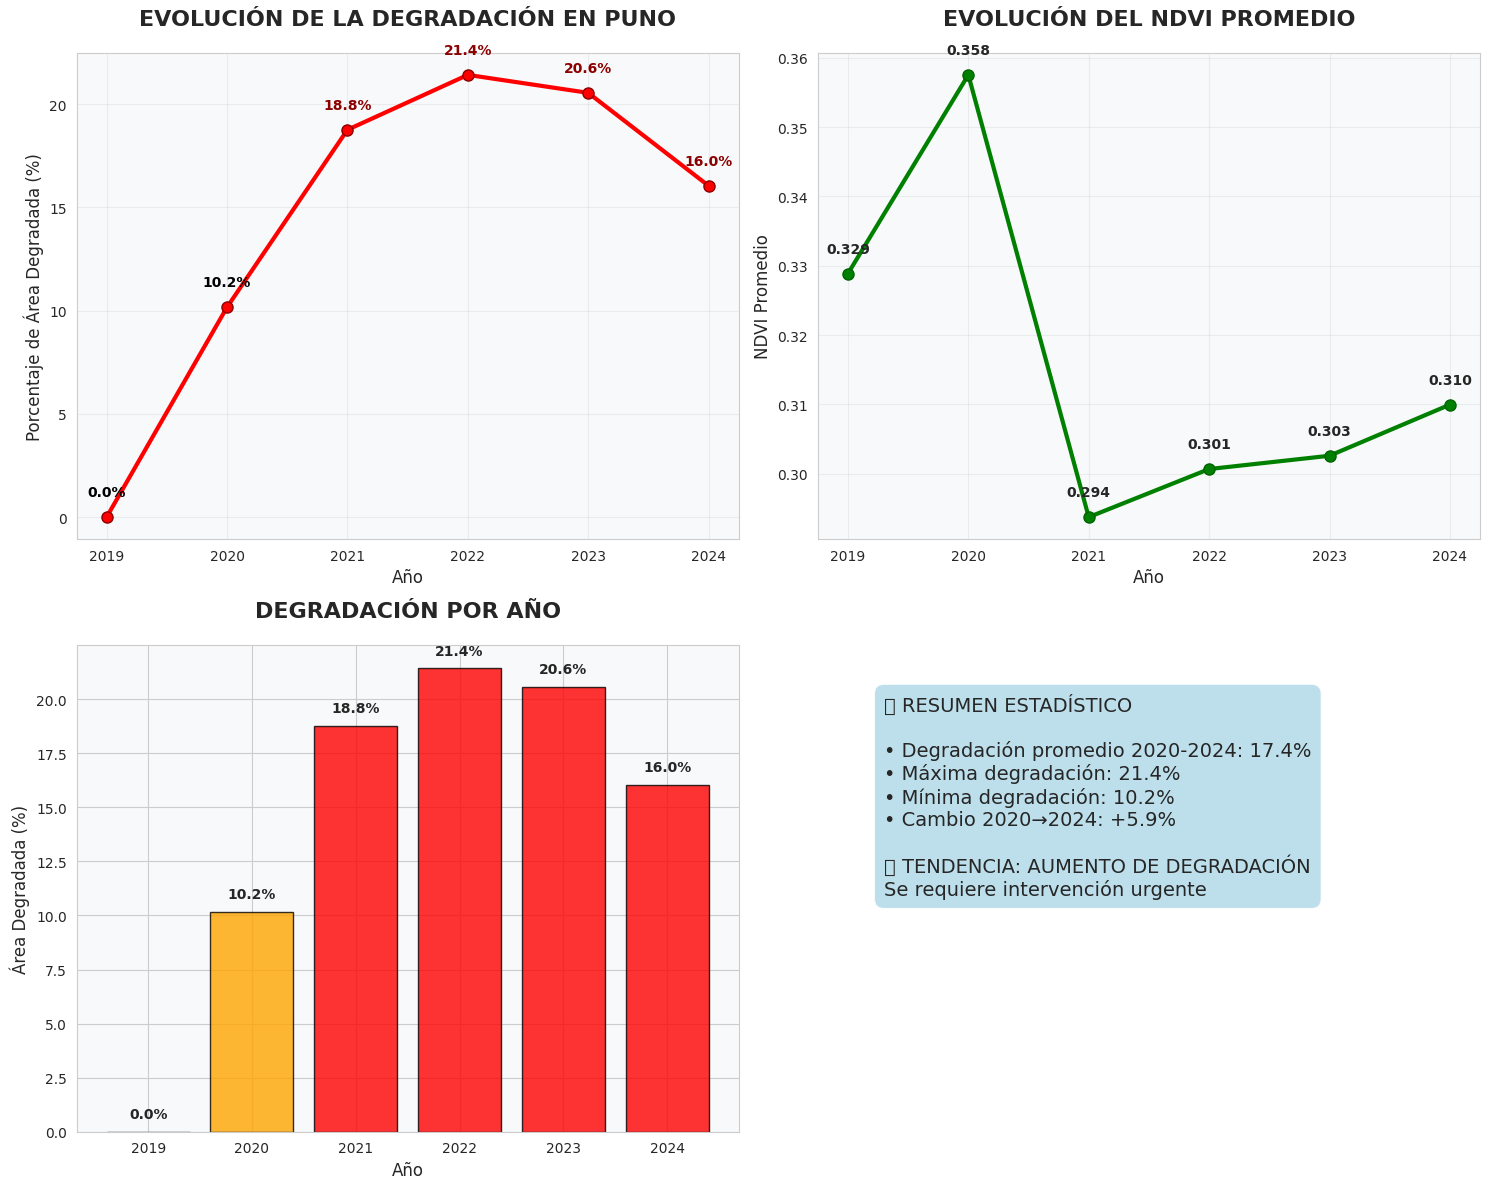


📋 TABLA RESUMEN DE DEGRADACIÓN
Año      Degradación (%) NDVI       Tendencia 
--------------------------------------------------
2019     0.0             0.329                
2020     10.2            0.358      +10.2%    
2021     18.8            0.294      +8.6%     
2022     21.4            0.301      +2.7%     
2023     20.6            0.303      -0.9%     
2024     16.0            0.310      -4.5%     

3️⃣ MAPAS DE EVOLUCIÓN ANUAL
🗺️ GENERANDO MAPA DE EVOLUCIÓN ANUAL...
💾 Mapa guardado: 'evolucion_degradacion_puno_2019_2024.html'
📍 Mostrando mapa interactivo...


Map(center=[-14.992503464366678, -69.93895981847153], controls=(WidgetControl(options=['position', 'transparen…


4️⃣ REPORTE FINAL
📋 EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO
2019: LÍNEA BASE | NDVI: 0.329
2020: 10.2% degradado 🟡 | NDVI: 0.358
2021: 18.8% degradado 🟡 | NDVI: 0.294
2022: 21.4% degradado 🔴 | NDVI: 0.301
2023: 20.6% degradado 🔴 | NDVI: 0.303
2024: 16.0% degradado 🟡 | NDVI: 0.310

🚨 SITUACIÓN 2024: 16.0% DE DEGRADACIÓN
   • ALERTA AMARILLA: Degradación moderada
   • Acciones prioritarias necesarias

✅ ANÁLISIS COMPLETADO EXITOSAMENTE


In [ ]:
# 6️⃣ Crear mapa de evolución anual CORREGIDO (sin marcadores problemáticos)
def crear_mapa_evolucion_anual(resultados_anuales):
    """Crear mapa con la evolución anual de la degradación"""

    print("🗺️ GENERANDO MAPA DE EVOLUCIÓN ANUAL...")

    Map = geemap.Map()
    Map.centerObject(geom_puno, 8)

    # Capa base de Puno
    Map.addLayer(geom_puno, {'color': 'blue', 'fillColor': '00000000'}, 'Departamento de Puno')

    # Añadir capas de degradación por año (CORREGIDO)
    colores_años = {
        2020: 'FF9999',  # Rojo claro
        2021: 'FF6666',  # Rojo medio
        2022: 'FF3333',  # Rojo
        2023: 'FF0000',  # Rojo intenso
        2024: 'CC0000'   # Rojo oscuro
    }

    for año, datos in resultados_anuales.items():
        if año != 2019:  # No mostrar 2019 (línea base)
            try:
                areas_degradadas = datos['areas_degradadas']

                # Asegurar proyección correcta
                areas_degradadas = areas_degradadas.setDefaultProjection(
                    crs='EPSG:4326',
                    scale=1000
                )

                # Añadir al mapa
                color = colores_años.get(año, 'FF0000')
                Map.addLayer(areas_degradadas.clip(geom_puno),
                            {'min': 0, 'max': 1, 'palette': ['00FF00', color]},
                            f'Degradación {año} ({datos["porcentaje_degradacion"]:.1f}%)')

            except Exception as e:
                print(f"⚠️ No se pudo cargar capa {año}: {e}")

    # Leyenda mejorada
    legend_dict = {
        'Límite Puno': '0000FF',
        'Degradación 2020': 'FF9999',
        'Degradación 2021': 'FF6666',
        'Degradación 2022': 'FF3333',
        'Degradación 2023': 'FF0000',
        'Degradación 2024': 'CC0000',
        'Áreas sin degradación': '00FF00'
    }

    Map.add_legend(legend_title="Evolución de la Degradación 2020-2024", legend_dict=legend_dict)

    # Añadir título usando HTML en lugar de marcadores problemáticos
    title_html = '''
    <div style="position: fixed;
                top: 10px; left: 50px; width: 300px; height: 100px;
                background-color: white; border:2px solid grey; z-index:9999;
                padding: 10px; border-radius: 5px;">
        <h4 style="margin:0; color:darkblue;">🌄 PUNO 2020-2024</h4>
        <p style="margin:5px 0; font-size:12px;">Evolución de la Degradación de Pastizales</p>
    </div>
    '''
    Map.add_html(title_html)

    return Map

# 7️⃣ Generar gráficos de evolución
def generar_graficos_evolucion(resultados_anuales):
    """Generar gráficos de evolución de la degradación"""

    print("📈 GENERANDO GRÁFICOS DE EVOLUCIÓN...")

    # Preparar datos
    años = []
    degradacion = []
    ndvi_valores = []

    for año, datos in sorted(resultados_anuales.items()):
        años.append(año)
        degradacion.append(datos['porcentaje_degradacion'])
        ndvi_valores.append(datos['ndvi_promedio'])

    # Crear gráficos
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Gráfico 1: Evolución de la degradación
    ax1.plot(años, degradacion, 'ro-', linewidth=3, markersize=8, markerfacecolor='red', markeredgecolor='darkred')
    ax1.set_title('EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Año', fontsize=12)
    ax1.set_ylabel('Porcentaje de Área Degradada (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor('#f8f9fa')

    # Añadir anotaciones
    for i, (año, valor) in enumerate(zip(años, degradacion)):
        color = 'darkred' if valor > 15 else 'black'
        ax1.annotate(f'{valor:.1f}%', (año, valor),
                    textcoords="offset points", xytext=(0,15),
                    ha='center', fontweight='bold', color=color, fontsize=10)

    # Gráfico 2: NDVI promedio
    ax2.plot(años, ndvi_valores, 'go-', linewidth=3, markersize=8, markerfacecolor='green', markeredgecolor='darkgreen')
    ax2.set_title('EVOLUCIÓN DEL NDVI PROMEDIO', fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Año', fontsize=12)
    ax2.set_ylabel('NDVI Promedio', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f8f9fa')

    # Añadir anotaciones NDVI
    for i, (año, valor) in enumerate(zip(años, ndvi_valores)):
        ax2.annotate(f'{valor:.3f}', (año, valor),
                    textcoords="offset points", xytext=(0,15),
                    ha='center', fontweight='bold', fontsize=10)

    # Gráfico 3: Barras de degradación
    colores_barras = ['green' if x < 5 else 'orange' if x < 15 else 'red' for x in degradacion]
    bars = ax3.bar(años, degradacion, color=colores_barras, alpha=0.8, edgecolor='black')
    ax3.set_title('DEGRADACIÓN POR AÑO', fontsize=16, fontweight='bold', pad=20)
    ax3.set_xlabel('Año', fontsize=12)
    ax3.set_ylabel('Área Degradada (%)', fontsize=12)
    ax3.set_facecolor('#f8f9fa')

    # Añadir valores en barras
    for bar, valor in zip(bars, degradacion):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Gráfico 4: Resumen estadístico
    ax4.axis('off')

    # Calcular estadísticas
    degradacion_sin_2019 = [degradacion[i] for i in range(1, len(degradacion))]
    cambio_total = degradacion[-1] - degradacion[1]  # Cambio desde 2020 a 2024

    resumen_text = "📊 RESUMEN ESTADÍSTICO\n\n"
    resumen_text += f"• Degradación promedio 2020-2024: {np.mean(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Máxima degradación: {max(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Mínima degradación: {min(degradacion_sin_2019):.1f}%\n"
    resumen_text += f"• Cambio 2020→2024: {cambio_total:+.1f}%\n\n"

    # Análisis de tendencia
    if cambio_total > 5:
        resumen_text += "🚨 TENDENCIA: AUMENTO DE DEGRADACIÓN\n"
        resumen_text += "Se requiere intervención urgente"
    elif cambio_total < -2:
        resumen_text += "✅ TENDENCIA: MEJORÍA\n"
        resumen_text += "Las medidas están funcionando"
    else:
        resumen_text += "📊 TENDENCIA: ESTABLE\n"
        resumen_text += "Mantener monitoreo"

    ax4.text(0.1, 0.9, resumen_text, fontsize=14, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
            transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

    # Mostrar tabla resumen
    print("\n📋 TABLA RESUMEN DE DEGRADACIÓN")
    print("="*50)
    print(f"{'Año':<8} {'Degradación (%)':<15} {'NDVI':<10} {'Tendencia':<10}")
    print("-"*50)
    for i, año in enumerate(años):
        tendencia = ""
        if i > 0:
            cambio = degradacion[i] - degradacion[i-1]
            tendencia = f"{cambio:+.1f}%"
        print(f"{año:<8} {degradacion[i]:<15.1f} {ndvi_valores[i]:<10.3f} {tendencia:<10}")

# 8️⃣ Sistema completo CORREGIDO
def sistema_completo_corregido():
    """Sistema completo con mapas de evolución anual"""

    print("🌄 SISTEMA DE MONITOREO - PUNO 2019-2024")
    print("🗺️ CON MAPAS DE EVOLUCIÓN ANUAL")
    print("="*60)

    # 1. Análisis de degradación anual
    print("\n1️⃣ ANÁLISIS DE DEGRADACIÓN ANUAL")
    resultados_anuales = analizar_degradacion_anual()

    if not resultados_anuales:
        print("❌ No se pudieron obtener resultados")
        return

    # 2. Gráficos de evolución
    print("\n2️⃣ GRÁFICOS DE EVOLUCIÓN")
    generar_graficos_evolucion(resultados_anuales)

    # 3. Mapas de evolución
    print("\n3️⃣ MAPAS DE EVOLUCIÓN ANUAL")
    mapa_evolucion = crear_mapa_evolucion_anual(resultados_anuales)

    if mapa_evolucion:
        # Guardar mapa
        mapa_evolucion.save('evolucion_degradacion_puno_2019_2024.html')
        print("💾 Mapa guardado: 'evolucion_degradacion_puno_2019_2024.html'")

        # Mostrar mapa
        print("📍 Mostrando mapa interactivo...")
        display(mapa_evolucion)
    else:
        print("❌ No se pudo generar el mapa")

    # 4. Reporte final
    print("\n4️⃣ REPORTE FINAL")
    print("="*50)
    print("📋 EVOLUCIÓN DE LA DEGRADACIÓN EN PUNO")
    print("="*50)

    for año, datos in sorted(resultados_anuales.items()):
        if año == 2019:
            print(f"{año}: LÍNEA BASE | NDVI: {datos['ndvi_promedio']:.3f}")
        else:
            alerta = "🔴" if datos['porcentaje_degradacion'] > 20 else "🟡" if datos['porcentaje_degradacion'] > 10 else "🟢"
            print(f"{año}: {datos['porcentaje_degradacion']:.1f}% degradado {alerta} | NDVI: {datos['ndvi_promedio']:.3f}")

    # Análisis de la situación 2024
    if 2024 in resultados_anuales:
        degradacion_2024 = resultados_anuales[2024]['porcentaje_degradacion']
        print(f"\n🚨 SITUACIÓN 2024: {degradacion_2024:.1f}% DE DEGRADACIÓN")

        if degradacion_2024 > 20:
            print("   • ALERTA ROJA: Degradación severa")
            print("   • Se requieren medidas urgentes")
        elif degradacion_2024 > 10:
            print("   • ALERTA AMARILLA: Degradación moderada")
            print("   • Acciones prioritarias necesarias")
        else:
            print("   • SITUACIÓN CONTROLADA")
            print("   • Mantener monitoreo")

    print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")

# EJECUTAR SISTEMA CORREGIDO
if __name__ == "__main__":
    sistema_completo_corregido()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ======================================================
# 🌍 EXPORTACIÓN DE MAPAS COMO GEO-TIFF (ADAPTADO A PUNO)
# ======================================================
def exportar_resultados_tiff(resultados_anuales, geom=geom_puno, nombre_base='Puno_Degradacion'):
    """
    Exporta los mapas NDVI, Anomalía y Áreas degradadas a GeoTIFF por año.
    Guarda los resultados en Google Drive (carpeta: GEE_Exports).
    """
    if not resultados_anuales:
        print("❌ No hay resultados para exportar")
        return

    print("💾 Iniciando exportación de mapas a GeoTIFF...")

    for año, datos in sorted(resultados_anuales.items()):
        if año == 2019:
            continue  # la línea base no se exporta como degradación

        try:
            ndvi = datos['ndvi_actual']
            areas_degradadas = datos['areas_degradadas']

            # Calcular anomalía NDVI (comparando con 2019)
            ndvi_2019 = resultados_anuales[2019]['ndvi_actual']
            anomalia_ndvi = ndvi.subtract(ndvi_2019).divide(ndvi_2019).rename('ANOMALIA_NDVI')

            # Diccionario de imágenes a exportar
            mapas_exportar = {
                f'{año}_NDVI': ndvi,
                f'{año}_Anomalia_NDVI': anomalia_ndvi,
                f'{año}_Areas_Degradadas': areas_degradadas
            }

            for nombre, imagen in mapas_exportar.items():
                descripcion = f"{nombre_base}_{nombre}"
                print(f"📤 Exportando {descripcion}.tif ...")

                tarea = ee.batch.Export.image.toDrive(
                    image=imagen.clip(geom),
                    description=descripcion,
                    folder='GEE_Exports',          # Carpeta destino en Google Drive
                    fileNamePrefix=descripcion,
                    region=geom.bounds().getInfo()['coordinates'],
                    scale=10,
                    maxPixels=1e13,
                    fileFormat='GeoTIFF'
                )

                tarea.start()
                print(f"✅ Tarea iniciada en Google Drive: {descripcion}")

        except Exception as e:
            print(f"⚠️ Error exportando año {año}: {e}")

    print("📦 Exportaciones iniciadas. Verifica tu Google Drive (carpeta: GEE_Exports)")


In [ ]:
    # 5. Exportación opcional a GeoTIFF
    print("\n5️⃣ EXPORTACIÓN DE RESULTADOS A GEO-TIFF")
    try:
        exportar_resultados_tiff(resultados_anuales, geom_puno, 'Puno_Monitoreo')
    except Exception as e:
        print(f"⚠️ Error durante exportación de TIFF: {e}")



5️⃣ EXPORTACIÓN DE RESULTADOS A GEO-TIFF
⚠️ Error durante exportación de TIFF: name 'resultados_anuales' is not defined
